---
title: "Beyond the Odds: Unraveling IVF Success with Machine Learning and Causal Inference"
author: "Chris Lake"
date: "2025-05-30"
format:
  html:
    code-fold: true
    code-summary: "Show code"
    toc: true
    toc-depth: 3
categories: [causal inference, machine learning, healthcare, fertility]
description: "A deep dive into UK fertility treatment data using LightGBM and propensity score matching to separate correlation from causation in IVF outcomes."
jupyter: python3
---

In [1]:
import pandas as pd

# Load Excel file - first 76 columns only
file_path = 'data/ar-2015-2016-xlsb.xlsx'

df = pd.read_excel(file_path, usecols=range(76))

print(f"Shape: {df.shape}")
print(f"\nColumns ({len(df.columns)}):")
print(df.columns.tolist())
df.head()

Shape: (158519, 76)

Columns (76):
['Patient Age at Treatment', 'Date patient started trying to become pregnant OR date of last pregnancy', 'Total Number of Previous cycles, Both IVF and DI', 'Total Number of Previous treatments, Both IVF and DI at clinic', 'Total Number of Previous IVF cycles', 'Total Number of Previous DI cycles', 'Total number of previous pregnancies, Both IVF and DI', 'Total number of IVF pregnancies', 'Total number of DI pregnancies', 'Total number of live births - conceived through IVF or DI', 'Total number of live births - conceived through IVF', 'Total number of live births - conceived through DI', 'Type of Infertility - Female Primary', 'Type of Infertility - Female Secondary', 'Type of Infertility - Male Primary', 'Type of Infertility - Male Secondary', 'Type of Infertility -Couple Primary', 'Type of Infertility -Couple Secondary', 'Cause  of Infertility - Tubal disease', 'Cause of Infertility - Ovulatory Disorder', 'Cause of Infertility - Male Factor', 'Caus

,Patient Age at Treatment,Date patient started trying to become pregnant OR date of last pregnancy,"Total Number of Previous cycles, Both IVF and DI","Total Number of Previous treatments, Both IVF and DI at clinic",Total Number of Previous IVF cycles,Total Number of Previous DI cycles,"Total number of previous pregnancies, Both IVF and DI",Total number of IVF pregnancies,Total number of DI pregnancies,Total number of live births - conceived through IVF or DI,...,Year of Treatment,Live Birth Occurrence,Number of Live Births,Early Outcome,Number of foetal sacs with fetal pulsation,Heart One Weeks Gestation,Heart One Birth Outcome,Heart One Birth Weight,Heart OneSex,Heart One Delivery Date
0,40-42,NaN,2,2,2,0,0,0,0,0,...,2016,1.0,1,Intrauterine Fetal Pulsation Seen,1,39,Live Birth,Between 3.5kg and 3.99Kg,F,999.0
1,45-50,NaN,3,3,3,0,0,0,0,0,...,2016,NaN,0,None,0,NaN,NaN,NaN,NaN,NaN
2,35-37,NaN,0,0,0,0,0,0,0,0,...,2016,NaN,0,NaN,0,NaN,NaN,NaN,NaN,NaN
3,18 - 34,NaN,2,2,2,0,0,0,0,0,...,2016,NaN,0,Biochemical Pregnancy Only,0,NaN,NaN,NaN,NaN,NaN
4,18 - 34,NaN,5,5,5,0,1,1,0,1,...,2016,NaN,0,None,0,NaN,NaN,NaN,NaN,NaN


In [2]:
# Load second file (2017-2018) - specific sheet
file_path_2 = 'data/ar-2017-2018-xlsb.xlsx'

df2 = pd.read_excel(file_path_2, sheet_name='Anonymised register')

print(f"Shape: {df2.shape}")
print(f"\nColumns ({len(df2.columns)}):") 
print(df2.columns.tolist())
df2.head()

Shape: (169616, 61)

Columns (61):
['Patient age at treatment', 'Total number of previous IVF cycles', 'Total number of previous DI cycles', 'Total number of previous pregnancies - IVF and DI', 'Total number of previous live births - IVF or DI', 'Causes of infertility - tubal disease', 'Causes of infertility - ovulatory disorder', 'Causes of infertility - male factor', 'Causes of infertility - patient unexplained', 'Causes of infertility - endometriosis', 'Main reason for producing embroys storing eggs', 'Stimulation used', 'Egg donor age at registration', 'Sperm donor age at registration', 'Donated embryo', 'Type of treatment - IVF or DI', 'Specific treatment type', 'PGT-M treatment', 'PGT-A treatment', 'Elective single embryo transfer', 'Egg source', 'Sperm source', 'Fresh cycle', 'Frozen cycle', 'Eggs thawed (0/1)', 'Fresh eggs collected', 'Fresh eggs stored (0/1)', 'Total eggs mixed', 'Total embryos created', 'Embryos transferred', 'Total embryos thawed', 'Embryos transferred from 

,Patient age at treatment,Total number of previous IVF cycles,Total number of previous DI cycles,Total number of previous pregnancies - IVF and DI,Total number of previous live births - IVF or DI,Causes of infertility - tubal disease,Causes of infertility - ovulatory disorder,Causes of infertility - male factor,Causes of infertility - patient unexplained,Causes of infertility - endometriosis,...,Heart three weeks gestation,Heart three birth outcome,Heart three birth weight,Heart three sex,Heart three birth congenital abnormalities,Heart three delivery date,Patient ethnicity,Partner ethnicity,Partner Type,Partner age
0,45-50,3,0,0.0,0,0,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,Black,Other,Male,NaN
1,18-34,0,0,NaN,NaN,0,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,White,Other,NaN,NaN
2,999,0,0,NaN,NaN,0,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,Other,Other,NaN,NaN
3,18-34,0,0,NaN,NaN,0,0,1,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,White,White,Male,18-34
4,18-34,1,0,NaN,0,0,0,1,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,White,White,Male,18-34


In [3]:
# Normalize column names: lowercase and underscores instead of spaces
df.columns = df.columns.str.lower().str.replace(' ', '_')
df2.columns = df2.columns.str.lower().str.replace(' ', '_')

print(f"df columns ({len(df.columns)}):")
print(df.columns.tolist())
print(f"\ndf2 columns ({len(df2.columns)}):")
print(df2.columns.tolist())

df columns (76):
['patient_age_at_treatment', 'date_patient_started_trying_to_become_pregnant_or_date_of_last_pregnancy', 'total_number_of_previous_cycles,_both_ivf_and_di', 'total_number_of_previous_treatments,_both_ivf_and_di_at_clinic', 'total_number_of_previous_ivf_cycles', 'total_number_of_previous_di_cycles', 'total_number_of_previous_pregnancies,_both_ivf_and_di', 'total_number_of_ivf_pregnancies', 'total_number_of_di_pregnancies', 'total_number_of_live_births_-_conceived_through_ivf_or_di', 'total_number_of_live_births_-_conceived_through_ivf', 'total_number_of_live_births_-_conceived_through_di', 'type_of_infertility_-_female_primary', 'type_of_infertility_-_female_secondary', 'type_of_infertility_-_male_primary', 'type_of_infertility_-_male_secondary', 'type_of_infertility_-couple_primary', 'type_of_infertility_-couple_secondary', 'cause__of_infertility_-_tubal_disease', 'cause_of_infertility_-_ovulatory_disorder', 'cause_of_infertility_-_male_factor', 'cause_of_infertility_-

In [4]:
# Find common columns between df and df2
common_cols = list(set(df.columns) & set(df2.columns))
common_cols_sorted = [c for c in df.columns if c in common_cols]  # Preserve order from df

print(f"Columns in df: {len(df.columns)}")
print(f"Columns in df2: {len(df2.columns)}")
print(f"Common columns: {len(common_cols_sorted)}")
print(f"\nCommon columns:")
print(common_cols_sorted)

# Columns only in df
only_df = [c for c in df.columns if c not in common_cols]
print(f"\nColumns only in df ({len(only_df)}): {only_df}")

# Columns only in df2
only_df2 = [c for c in df2.columns if c not in common_cols]
print(f"\nColumns only in df2 ({len(only_df2)}): {only_df2}")

Columns in df: 76
Columns in df2: 61
Common columns: 29

Common columns:
['patient_age_at_treatment', 'total_number_of_previous_ivf_cycles', 'total_number_of_previous_di_cycles', 'main_reason_for_producing_embroys_storing_eggs', 'stimulation_used', 'egg_donor_age_at_registration', 'sperm_donor_age_at_registration', 'donated_embryo', 'type_of_treatment_-_ivf_or_di', 'specific_treatment_type', 'elective_single_embryo_transfer', 'egg_source', 'fresh_cycle', 'frozen_cycle', 'fresh_eggs_collected', 'total_eggs_mixed', 'total_embryos_created', 'total_embryos_thawed', 'embryos_stored_for_use_by_patient', 'date_of_embryo_transfer', 'year_of_treatment', 'live_birth_occurrence', 'number_of_live_births', 'early_outcome', 'number_of_foetal_sacs_with_fetal_pulsation', 'heart_one_weeks_gestation', 'heart_one_birth_outcome', 'heart_one_birth_weight', 'heart_one_delivery_date']

Columns only in df (47): ['date_patient_started_trying_to_become_pregnant_or_date_of_last_pregnancy', 'total_number_of_previ

In [5]:
df.describe()

,date_patient_started_trying_to_become_pregnant_or_date_of_last_pregnancy,total_number_of_di_pregnancies,total_number_of_live_births_-_conceived_through_ivf_or_di,total_number_of_live_births_-_conceived_through_ivf,total_number_of_live_births_-_conceived_through_di,type_of_infertility_-_female_primary,type_of_infertility_-_female_secondary,type_of_infertility_-_male_primary,type_of_infertility_-_male_secondary,type_of_infertility_-couple_primary,...,date_of_egg_collection,date_of_egg_thawing,date_of_egg_mixing,date_of_embryo_thawing,date_of_embryo_transfer,year_of_treatment,live_birth_occurrence,number_of_live_births,number_of_foetal_sacs_with_fetal_pulsation,heart_one_delivery_date
count,617.000000,158519.000000,158519.000000,158519.000000,158519.000000,158519.000000,158519.000000,158519.000000,158519.000000,158519.000000,...,104463.0,1093.000000,97807.000000,38901.000000,116577.000000,158519.000000,38082.0,158519.000000,158519.000000,37403.000000
mean,13.247974,0.012024,0.135296,0.126389,0.008907,0.003501,0.001438,0.003274,0.001438,0.003722,...,0.0,5.489478,2.914986,0.623172,5.639989,2015.513774,1.0,0.268876,0.311603,1667.621929
std,3.087748,0.124247,0.366885,0.355476,0.100511,0.059067,0.037898,0.057126,0.037898,0.060894,...,0.0,73.847030,53.848110,24.286163,52.725893,0.499812,0.0,0.504899,0.546304,482.478536
min,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.000000,0.000000,0.000000,0.000000,2015.000000,1.0,0.000000,0.000000,999.000000
25%,11.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.000000,0.000000,0.000000,0.000000,2015.000000,1.0,0.000000,0.000000,999.000000
50%,13.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.000000,0.000000,0.000000,3.000000,2016.000000,1.0,0.000000,0.000000,2016.000000
75%,15.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.000000,0.000000,0.000000,5.000000,2016.000000,1.0,0.000000,1.000000,2016.000000
max,20.000000,4.000000,5.000000,5.000000,3.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,0.0,999.000000,999.000000,999.000000,999.000000,2016.000000,1.0,4.000000,40.000000,2016.000000


In [6]:
pd.set_option('display.max_rows', None)
df.isnull().sum()

patient_age_at_treatment                                                         0
date_patient_started_trying_to_become_pregnant_or_date_of_last_pregnancy    157902
total_number_of_previous_cycles,_both_ivf_and_di                                 0
total_number_of_previous_treatments,_both_ivf_and_di_at_clinic                   0
total_number_of_previous_ivf_cycles                                              0
total_number_of_previous_di_cycles                                               0
total_number_of_previous_pregnancies,_both_ivf_and_di                            0
total_number_of_ivf_pregnancies                                                  0
total_number_of_di_pregnancies                                                   0
total_number_of_live_births_-_conceived_through_ivf_or_di                        0
total_number_of_live_births_-_conceived_through_ivf                              0
total_number_of_live_births_-_conceived_through_di                               0
type

In [7]:
df2.dtypes

patient_age_at_treatment                              object
total_number_of_previous_ivf_cycles                   object
total_number_of_previous_di_cycles                    object
total_number_of_previous_pregnancies_-_ivf_and_di    float64
total_number_of_previous_live_births_-_ivf_or_di      object
causes_of_infertility_-_tubal_disease                  int64
causes_of_infertility_-_ovulatory_disorder             int64
causes_of_infertility_-_male_factor                    int64
causes_of_infertility_-_patient_unexplained            int64
causes_of_infertility_-_endometriosis                  int64
main_reason_for_producing_embroys_storing_eggs        object
stimulation_used                                       int64
egg_donor_age_at_registration                         object
sperm_donor_age_at_registration                       object
donated_embryo                                       float64
type_of_treatment_-_ivf_or_di                         object
specific_treatment_type 

In [8]:
df2['embryos_transferred'].value_counts()

embryos_transferred
1.0    81339
2.0    37628
0.0    37499
3.0     1868
Name: count, dtype: int64

In [9]:
# ============================================================
# INVESTIGATE NULLS: Previous Pregnancies & Live Births
# ============================================================

# Check null rates
print("Null counts:")
print(f"  total_number_of_previous_pregnancies_-_ivf_and_di: {df2['total_number_of_previous_pregnancies_-_ivf_and_di'].isnull().sum():,} ({df2['total_number_of_previous_pregnancies_-_ivf_and_di'].isnull().mean()*100:.1f}%)")
print(f"  total_number_of_previous_live_births_-_ivf_or_di:  {df2['total_number_of_previous_live_births_-_ivf_or_di'].isnull().sum():,} ({df2['total_number_of_previous_live_births_-_ivf_or_di'].isnull().mean()*100:.1f}%)")

# Are they null together?
both_null = (df2['total_number_of_previous_pregnancies_-_ivf_and_di'].isnull() & 
             df2['total_number_of_previous_live_births_-_ivf_or_di'].isnull()).sum()
print(f"\nBoth null together: {both_null:,}")

# Check if nulls correlate with other variables
print("\n" + "="*60)
print("NULL vs NON-NULL COMPARISON")
print("="*60)

preg_null = df2['total_number_of_previous_pregnancies_-_ivf_and_di'].isnull()

# Compare by previous IVF cycles
print("\nBy total_number_of_previous_ivf_cycles:")
print(df2.groupby(preg_null)['total_number_of_previous_ivf_cycles'].value_counts(normalize=True).unstack(level=0).head(10))

# Compare by treatment type
print("\nBy type_of_treatment_-_ivf_or_di:")
print(pd.crosstab(df2['type_of_treatment_-_ivf_or_di'], preg_null, normalize='columns'))

# Compare by specific treatment type
print("\nBy specific_treatment_type:")
print(pd.crosstab(df2['specific_treatment_type'], preg_null, normalize='columns'))

# Check outcome distribution
print("\nBy embryos_transferred (target):")
print(pd.crosstab(df2['embryos_transferred'], preg_null, normalize='columns'))

Null counts:
  total_number_of_previous_pregnancies_-_ivf_and_di: 126,928 (74.8%)
  total_number_of_previous_live_births_-_ivf_or_di:  64,529 (38.0%)

Both null together: 64,529

NULL vs NON-NULL COMPARISON

By total_number_of_previous_ivf_cycles:
total_number_of_previous_pregnancies_-_ivf_and_di     False     True 
total_number_of_previous_ivf_cycles                                  
0                                                  0.188554  0.509809
1                                                  0.213409  0.248338
2                                                  0.198651  0.122361
3                                                  0.145708  0.058324
4                                                  0.094359  0.028890
5                                                  0.059244  0.014741
>5                                                 0.100075  0.017538

By type_of_treatment_-_ivf_or_di:
total_number_of_previous_pregnancies_-_ivf_and_di     False     True 
type_of_treatment

In [10]:
# Create missing flags instead of imputing
df2['prev_pregnancies_missing'] = df2['total_number_of_previous_pregnancies_-_ivf_and_di'].isnull().astype(int)
df2['prev_live_births_missing'] = df2['total_number_of_previous_live_births_-_ivf_or_di'].isnull().astype(int)

# Fill nulls with 0 (or -1 to distinguish from actual 0)
df2['total_number_of_previous_pregnancies_-_ivf_and_di'] = df2['total_number_of_previous_pregnancies_-_ivf_and_di'].fillna(0)
df2['total_number_of_previous_live_births_-_ivf_or_di'] = df2['total_number_of_previous_live_births_-_ivf_or_di'].fillna(0)

In [11]:
# ============================================================
# PREPROCESSING FOR MODEL (EXCLUDING ELECTIVE SET CASES)
# ============================================================
# Target: embryos_transferred (3-class: 0, 1, 2+)
# Using df2 (2017-2018 data)
# EXCLUDING cases where elective single embryo transfer = 1

print("="*70)
print("FILTERING: EXCLUDING ELECTIVE SINGLE EMBRYO TRANSFER CASES")
print("="*70)

# Check ESET distribution first
print("\nElective Single Embryo Transfer distribution:")
print(df2['elective_single_embryo_transfer'].value_counts(dropna=False))

# Define feature columns (excluding ESET entirely)
feature_cols = [
    'patient_age_at_treatment',
    'total_number_of_previous_ivf_cycles',
    'total_number_of_previous_di_cycles',
    'total_number_of_previous_pregnancies_-_ivf_and_di',
    'total_number_of_previous_live_births_-_ivf_or_di',
    'causes_of_infertility_-_tubal_disease',
    'causes_of_infertility_-_ovulatory_disorder',
    'causes_of_infertility_-_male_factor',
    'causes_of_infertility_-_patient_unexplained',
    'causes_of_infertility_-_endometriosis',
    'main_reason_for_producing_embroys_storing_eggs',
    'stimulation_used',
    'egg_donor_age_at_registration',
    'sperm_donor_age_at_registration',
    'donated_embryo',
    'type_of_treatment_-_ivf_or_di',
    'specific_treatment_type',
    'pgt-m_treatment',
    'pgt-a_treatment',
    # 'elective_single_embryo_transfer',  # REMOVED - tautological predictor
    'egg_source',
    'sperm_source'
]

target_col = 'embryos_transferred'

# Create working dataframe
model_df = df2[feature_cols + [target_col, 'elective_single_embryo_transfer']].copy()

# Remove rows with missing target
print(f"\nRows before any filtering: {len(model_df):,}")
model_df = model_df.dropna(subset=[target_col])
print(f"Rows after dropping null target: {len(model_df):,}")

# FILTER OUT ESET CASES (elective_single_embryo_transfer == 1)
eset_cases = (model_df['elective_single_embryo_transfer'] == 1).sum()
print(f"\nElective SET cases being removed: {eset_cases:,}")
model_df = model_df[model_df['elective_single_embryo_transfer'] != 1]
print(f"Rows after excluding ESET: {len(model_df):,}")

# Drop the ESET column now that we've filtered
model_df = model_df.drop(columns=['elective_single_embryo_transfer'])

# Create 3-class target: 0, 1, 2+
model_df['target'] = model_df[target_col].apply(lambda x: 0 if x == 0 else (1 if x == 1 else 2))
print("\nTarget distribution (after excluding ESET):")
print(model_df['target'].value_counts().sort_index())
print(f"\nPercentages:")
print((model_df['target'].value_counts(normalize=True).sort_index() * 100).round(1))

FILTERING: EXCLUDING ELECTIVE SINGLE EMBRYO TRANSFER CASES

Elective Single Embryo Transfer distribution:
elective_single_embryo_transfer
0.0    105149
1.0     53185
NaN     11282
Name: count, dtype: int64

Rows before any filtering: 169,616
Rows after dropping null target: 158,334

Elective SET cases being removed: 53,185
Rows after excluding ESET: 105,149

Target distribution (after excluding ESET):
target
0    37499
1    28172
2    39478
Name: count, dtype: int64

Percentages:
target
0    35.7
1    26.8
2    37.5
Name: proportion, dtype: float64


In [12]:
# ============================================================
# HANDLE MISSING VALUES & CREATE FLAGS
# ============================================================

# 1. Create missing flags for columns with informative nulls
model_df['prev_pregnancies_missing'] = model_df['total_number_of_previous_pregnancies_-_ivf_and_di'].isnull().astype(int)
model_df['prev_live_births_missing'] = model_df['total_number_of_previous_live_births_-_ivf_or_di'].isnull().astype(int)
model_df['egg_donor_age_missing'] = model_df['egg_donor_age_at_registration'].isnull().astype(int)
model_df['sperm_donor_age_missing'] = model_df['sperm_donor_age_at_registration'].isnull().astype(int)
# Removed: elective_set_missing (ESET excluded from analysis)

# 2. Fill numeric nulls
model_df['total_number_of_previous_pregnancies_-_ivf_and_di'] = model_df['total_number_of_previous_pregnancies_-_ivf_and_di'].fillna(0)
model_df['total_number_of_previous_live_births_-_ivf_or_di'] = model_df['total_number_of_previous_live_births_-_ivf_or_di'].fillna('0')
model_df['donated_embryo'] = model_df['donated_embryo'].fillna(0)

# 3. Handle '999' values and fill categorical nulls
model_df['patient_age_at_treatment'] = model_df['patient_age_at_treatment'].replace('999', 'Unknown')
model_df['egg_donor_age_at_registration'] = model_df['egg_donor_age_at_registration'].fillna('Not_Donor')
model_df['sperm_donor_age_at_registration'] = model_df['sperm_donor_age_at_registration'].fillna('Not_Donor')
model_df['main_reason_for_producing_embroys_storing_eggs'] = model_df['main_reason_for_producing_embroys_storing_eggs'].fillna('Unknown')
model_df['egg_source'] = model_df['egg_source'].fillna('Unknown')
model_df['sperm_source'] = model_df['sperm_source'].fillna('Unknown')

print("Missing values after handling:")
print(model_df.isnull().sum())

Missing values after handling:
patient_age_at_treatment                             0
total_number_of_previous_ivf_cycles                  0
total_number_of_previous_di_cycles                   0
total_number_of_previous_pregnancies_-_ivf_and_di    0
total_number_of_previous_live_births_-_ivf_or_di     0
causes_of_infertility_-_tubal_disease                0
causes_of_infertility_-_ovulatory_disorder           0
causes_of_infertility_-_male_factor                  0
causes_of_infertility_-_patient_unexplained          0
causes_of_infertility_-_endometriosis                0
main_reason_for_producing_embroys_storing_eggs       0
stimulation_used                                     0
egg_donor_age_at_registration                        0
sperm_donor_age_at_registration                      0
donated_embryo                                       0
type_of_treatment_-_ivf_or_di                        0
specific_treatment_type                              0
pgt-m_treatment                   

In [13]:
# ============================================================
# ENCODE CATEGORICAL VARIABLES
# ============================================================
from sklearn.preprocessing import LabelEncoder

# Define categorical columns to encode
cat_cols_to_encode = [
    'patient_age_at_treatment',
    'total_number_of_previous_ivf_cycles',
    'total_number_of_previous_di_cycles',
    'total_number_of_previous_live_births_-_ivf_or_di',
    'main_reason_for_producing_embroys_storing_eggs',
    'egg_donor_age_at_registration',
    'sperm_donor_age_at_registration',
    'type_of_treatment_-_ivf_or_di',
    'specific_treatment_type',
    'egg_source',
    'sperm_source'
]

# Label encode each categorical column
label_encoders = {}
for col in cat_cols_to_encode:
    le = LabelEncoder()
    model_df[col] = le.fit_transform(model_df[col].astype(str))
    label_encoders[col] = le
    print(f"{col}: {len(le.classes_)} categories")

print("\nData types after encoding:")
print(model_df.dtypes)

patient_age_at_treatment: 7 categories
total_number_of_previous_ivf_cycles: 7 categories
total_number_of_previous_di_cycles: 7 categories
total_number_of_previous_live_births_-_ivf_or_di: 5 categories
main_reason_for_producing_embroys_storing_eggs: 6 categories
egg_donor_age_at_registration: 6 categories
sperm_donor_age_at_registration: 8 categories
type_of_treatment_-_ivf_or_di: 1 categories
specific_treatment_type: 6 categories
egg_source: 2 categories
sperm_source: 3 categories

Data types after encoding:
patient_age_at_treatment                               int64
total_number_of_previous_ivf_cycles                    int64
total_number_of_previous_di_cycles                     int64
total_number_of_previous_pregnancies_-_ivf_and_di    float64
total_number_of_previous_live_births_-_ivf_or_di       int64
causes_of_infertility_-_tubal_disease                  int64
causes_of_infertility_-_ovulatory_disorder             int64
causes_of_infertility_-_male_factor                    int6

In [14]:
# ============================================================
# PREPARE FEATURES AND TRAIN/TEST SPLIT
# ============================================================
from sklearn.model_selection import train_test_split

# Define final feature columns (original + missing flags)
# Note: elective_single_embryo_transfer and elective_set_missing REMOVED
final_features = feature_cols + [
    'prev_pregnancies_missing',
    'prev_live_births_missing', 
    'egg_donor_age_missing',
    'sperm_donor_age_missing'
]

X = model_df[final_features]
y = model_df['target']

# Train/test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {len(X_train):,} samples")
print(f"Test set: {len(X_test):,} samples")
print(f"\nTarget distribution in training set:")
print(y_train.value_counts(normalize=True).sort_index())

Training set: 84,119 samples
Test set: 21,030 samples

Target distribution in training set:
target
0    0.356626
1    0.267930
2    0.375444
Name: proportion, dtype: float64


In [15]:
# ============================================================
# TRAIN LIGHTGBM MODEL (3-CLASS)
# ============================================================
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Initialize LightGBM classifier for multi-class
lgb_model = LGBMClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    objective='multiclass',
    num_class=3,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

# Train the model
print("Training LightGBM model...")
lgb_model.fit(X_train, y_train)
print("Training complete!")

# Predictions
y_pred = lgb_model.predict(X_test)

# Evaluation
print("\n" + "="*60)
print("CLASSIFICATION REPORT")
print("="*60)
print(classification_report(y_test, y_pred, target_names=['0 embryos', '1 embryo', '2+ embryos']))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Training LightGBM model...
Training complete!

CLASSIFICATION REPORT
              precision    recall  f1-score   support

   0 embryos       0.83      0.70      0.76      7500
    1 embryo       0.58      0.48      0.53      5634
  2+ embryos       0.57      0.72      0.63      7896

    accuracy                           0.65     21030
   macro avg       0.66      0.63      0.64     21030
weighted avg       0.66      0.65      0.65     21030


Confusion Matrix:
[[5258  353 1889]
 [ 460 2716 2458]
 [ 629 1586 5681]]


Top 15 Most Important Features:
                                          feature  importance
              total_number_of_previous_ivf_cycles        2677
                         patient_age_at_treatment        2638
                          specific_treatment_type        1730
                  sperm_donor_age_at_registration        1431
                    egg_donor_age_at_registration        1099
               total_number_of_previous_di_cycles        1012
total_number_of_previous_pregnancies_-_ivf_and_di         990
              causes_of_infertility_-_male_factor         886
 total_number_of_previous_live_births_-_ivf_or_di         856
   main_reason_for_producing_embroys_storing_eggs         606
      causes_of_infertility_-_patient_unexplained         595
       causes_of_infertility_-_ovulatory_disorder         545
                                 stimulation_used         507
            causes_of_infertility_-_endometriosis         437
            causes_of_infertility_-_tu

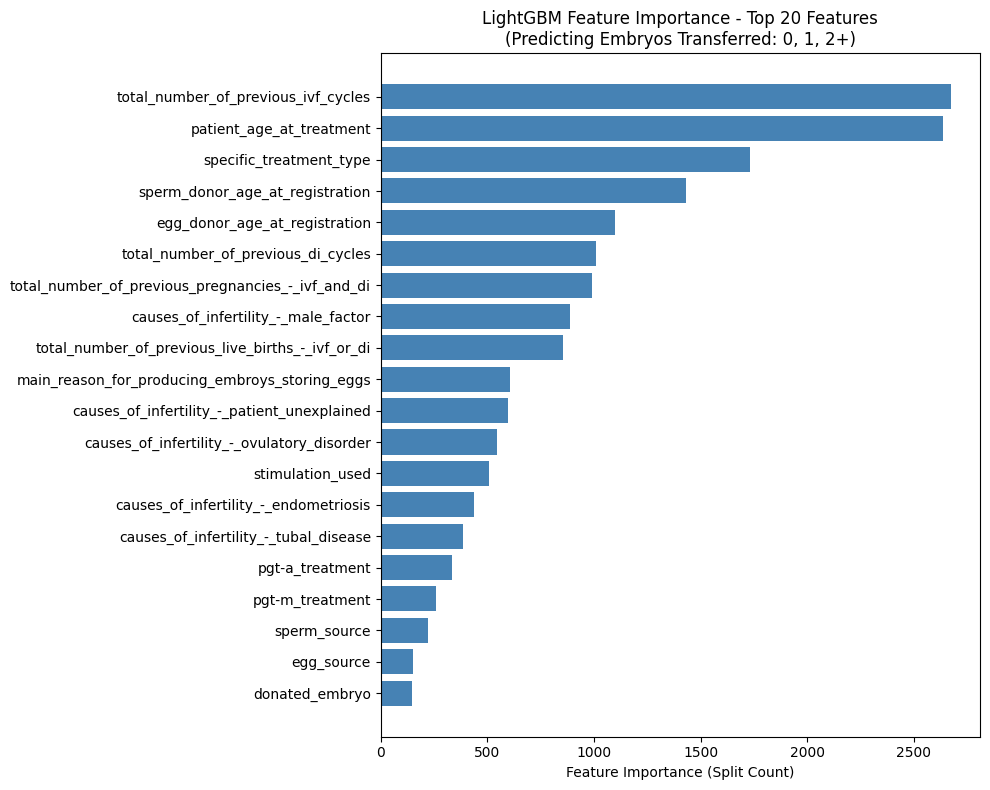

In [16]:
# ============================================================
# FEATURE IMPORTANCE
# ============================================================
import matplotlib.pyplot as plt

# Get feature importances
feature_importance = pd.DataFrame({
    'feature': final_features,
    'importance': lgb_model.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 15 Most Important Features:")
print(feature_importance.head(15).to_string(index=False))

# Plot feature importance
fig, ax = plt.subplots(figsize=(10, 8))
top_n = 20
top_features = feature_importance.head(top_n)

ax.barh(range(len(top_features)), top_features['importance'].values, color='steelblue')
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features['feature'].values)
ax.invert_yaxis()
ax.set_xlabel('Feature Importance (Split Count)')
ax.set_title('LightGBM Feature Importance - Top 20 Features\n(Predicting Embryos Transferred: 0, 1, 2+)')
plt.tight_layout()
plt.show()

/Users/chlake/.pyenv/versions/3.11.8/envs/bkng-data-cli-env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SHAP values type: <class 'numpy.ndarray'>
SHAP values shape: (5000, 25, 3)

SHAP Summary Plot - Class 1 (1 embryo)


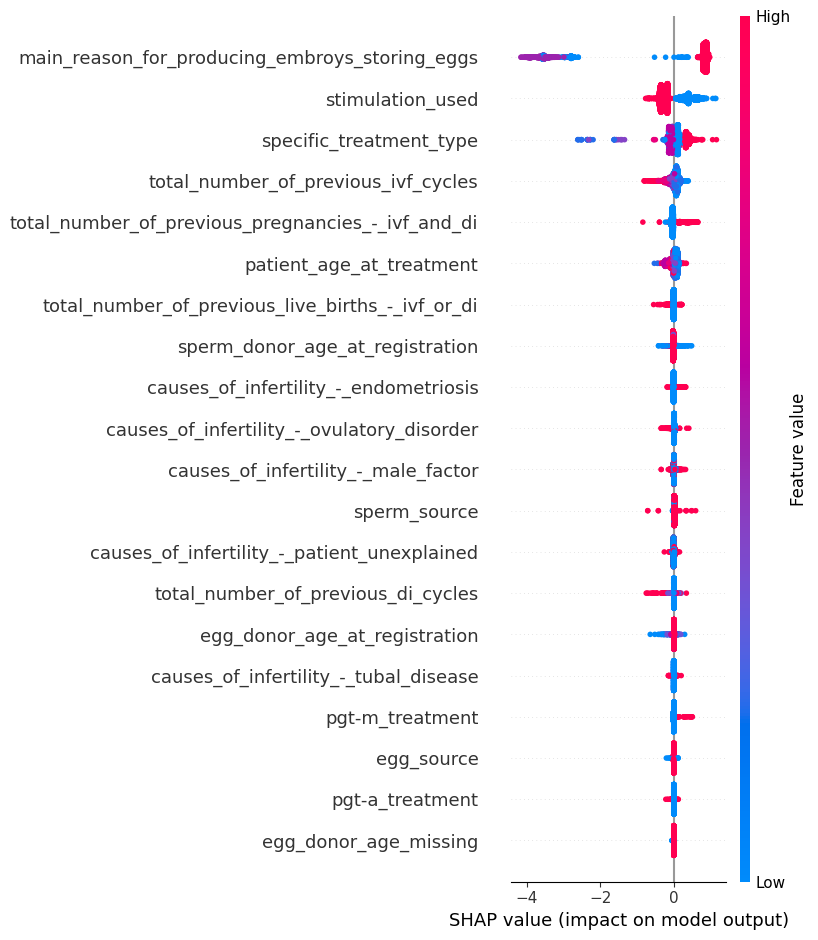

In [17]:
# ============================================================
# SHAP VALUES FOR DEEPER INTERPRETATION
# ============================================================
import shap

# Create SHAP explainer
explainer = shap.TreeExplainer(lgb_model)

# Calculate SHAP values for test set (sample for speed)
sample_size = min(5000, len(X_test))
X_sample = X_test.sample(n=sample_size, random_state=42)
shap_values = explainer.shap_values(X_sample)

# Check structure
print(f"SHAP values type: {type(shap_values)}")
if isinstance(shap_values, list):
    print(f"Number of classes: {len(shap_values)}")
    print(f"Shape per class: {shap_values[0].shape}")
else:
    print(f"SHAP values shape: {shap_values.shape}")

# Summary plot - use class 1 (single embryo transfer) as example
print("\nSHAP Summary Plot - Class 1 (1 embryo)")
if isinstance(shap_values, list):
    shap.summary_plot(shap_values[1], X_sample, feature_names=final_features)
else:
    shap.summary_plot(shap_values[:, :, 1], X_sample, feature_names=final_features)

CLASS 0: NO EMBRYOS TRANSFERRED
Features that INCREASE probability of 0 embryos (no transfer)



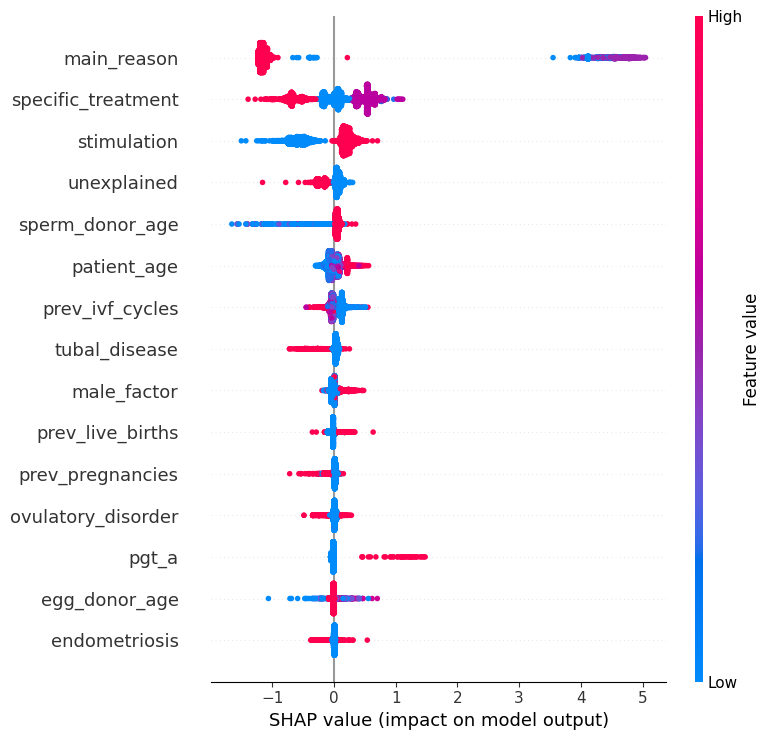

In [18]:
# ============================================================
# SHAP SUMMARY: CLASS 0 (0 EMBRYOS TRANSFERRED)
# ============================================================

# Create shorter feature names for display
# Note: elective_single_embryo_transfer REMOVED from analysis
short_names = {
    'patient_age_at_treatment': 'patient_age',
    'total_number_of_previous_ivf_cycles': 'prev_ivf_cycles',
    'total_number_of_previous_di_cycles': 'prev_di_cycles',
    'total_number_of_previous_pregnancies_-_ivf_and_di': 'prev_pregnancies',
    'total_number_of_previous_live_births_-_ivf_or_di': 'prev_live_births',
    'causes_of_infertility_-_tubal_disease': 'tubal_disease',
    'causes_of_infertility_-_ovulatory_disorder': 'ovulatory_disorder',
    'causes_of_infertility_-_male_factor': 'male_factor',
    'causes_of_infertility_-_patient_unexplained': 'unexplained',
    'causes_of_infertility_-_endometriosis': 'endometriosis',
    'main_reason_for_producing_embroys_storing_eggs': 'main_reason',
    'stimulation_used': 'stimulation',
    'egg_donor_age_at_registration': 'egg_donor_age',
    'sperm_donor_age_at_registration': 'sperm_donor_age',
    'donated_embryo': 'donated_embryo',
    'type_of_treatment_-_ivf_or_di': 'treatment_type',
    'specific_treatment_type': 'specific_treatment',
    'pgt-m_treatment': 'pgt_m',
    'pgt-a_treatment': 'pgt_a',
    'egg_source': 'egg_source',
    'sperm_source': 'sperm_source',
    'prev_pregnancies_missing': 'prev_preg_missing',
    'prev_live_births_missing': 'prev_births_missing',
    'egg_donor_age_missing': 'egg_donor_missing',
    'sperm_donor_age_missing': 'sperm_donor_missing'
}
short_feature_names = [short_names.get(f, f) for f in final_features]

# Class 0: No embryos transferred
print("="*70)
print("CLASS 0: NO EMBRYOS TRANSFERRED")
print("="*70)
print("Features that INCREASE probability of 0 embryos (no transfer)")
print()

if isinstance(shap_values, list):
    class_shap = shap_values[0]
else:
    class_shap = shap_values[:, :, 0]

plt.figure(figsize=(10, 8))
shap.summary_plot(class_shap, X_sample, feature_names=short_feature_names, max_display=15)
plt.show()

CLASS 1: SINGLE EMBRYO TRANSFERRED
Features that INCREASE probability of 1 embryo transfer



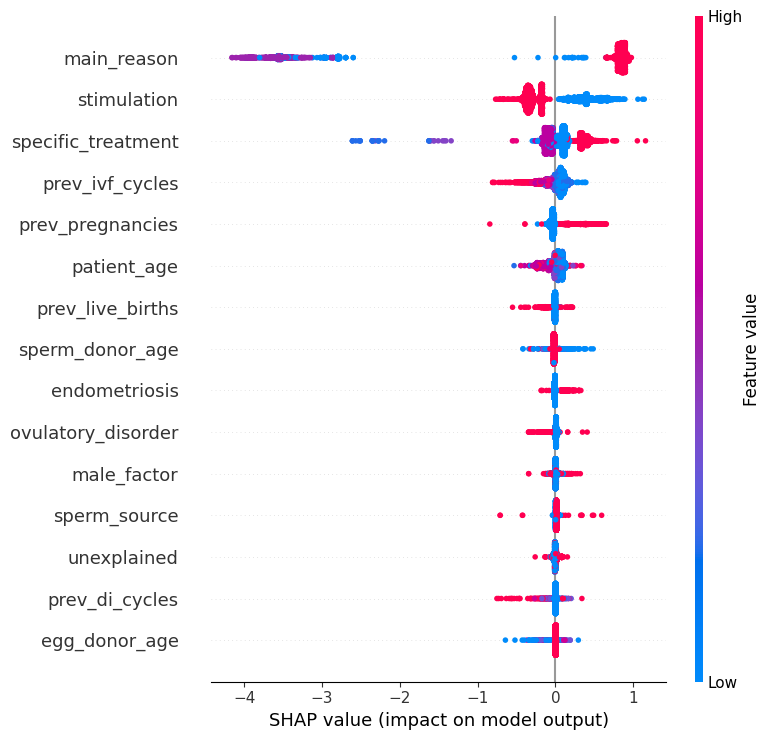

In [19]:
# ============================================================
# SHAP SUMMARY: CLASS 1 (1 EMBRYO TRANSFERRED)
# ============================================================

print("="*70)
print("CLASS 1: SINGLE EMBRYO TRANSFERRED")
print("="*70)
print("Features that INCREASE probability of 1 embryo transfer")
print()

if isinstance(shap_values, list):
    class_shap = shap_values[1]
else:
    class_shap = shap_values[:, :, 1]

plt.figure(figsize=(10, 8))
shap.summary_plot(class_shap, X_sample, feature_names=short_feature_names, max_display=15)
plt.show()

CLASS 2: MULTIPLE EMBRYOS TRANSFERRED (2+)
Features that INCREASE probability of 2+ embryo transfer



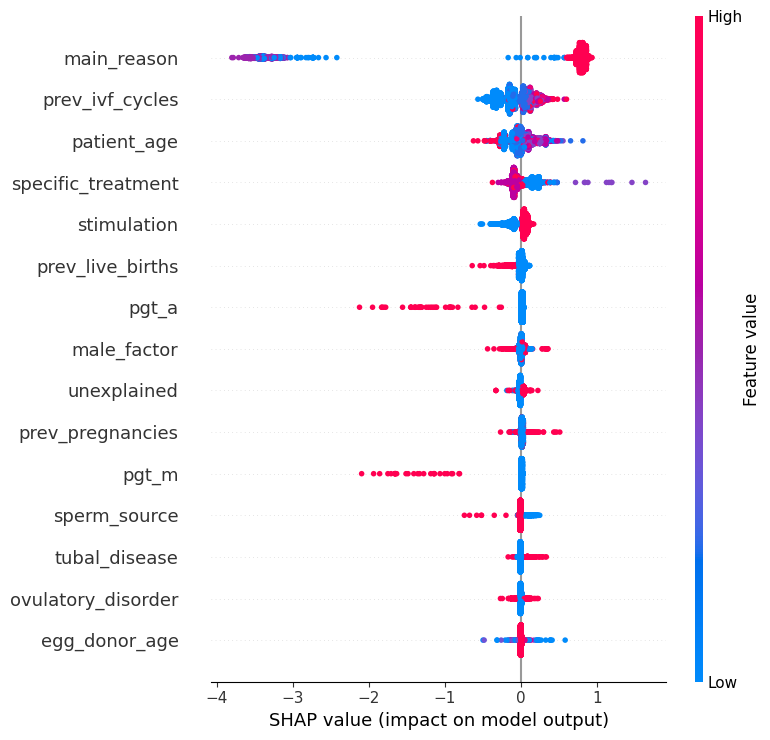

In [20]:
# ============================================================
# SHAP SUMMARY: CLASS 2 (2+ EMBRYOS TRANSFERRED)
# ============================================================

print("="*70)
print("CLASS 2: MULTIPLE EMBRYOS TRANSFERRED (2+)")
print("="*70)
print("Features that INCREASE probability of 2+ embryo transfer")
print()

if isinstance(shap_values, list):
    class_shap = shap_values[2]
else:
    class_shap = shap_values[:, :, 2]

plt.figure(figsize=(10, 8))
shap.summary_plot(class_shap, X_sample, feature_names=short_feature_names, max_display=15)
plt.show()

# Understanding SHAP Values

## What are SHAP values?

**SHAP (SHapley Additive exPlanations)** values explain how much each feature contributes to pushing a prediction away from the baseline (average) prediction toward the actual prediction.

## How to read the summary plots:

### The X-axis (SHAP value)
- **Positive SHAP value (right side)**: The feature pushes the prediction **toward** this class
- **Negative SHAP value (left side)**: The feature pushes the prediction **away** from this class
- **Zero**: The feature has no impact on this prediction

### The color (feature value)
- **Red**: High feature value (e.g., older age, more previous cycles)
- **Blue**: Low feature value (e.g., younger age, fewer previous cycles)

### The Y-axis (features)
- Features are sorted by importance (most impactful at top)
- Each dot represents one patient in the sample

## Example interpretation:

If you see **`patient_age`** with:
- Red dots on the **right** → Higher age increases probability of this class
- Blue dots on the **right** → Lower age increases probability of this class
- Wide spread → Age has a strong, variable effect
- Narrow spread → Age has a consistent but smaller effect

## For your IVF model:

- **Class 0 (0 embryos)**: Features that lead to no transfer (e.g., cycle cancellation, no viable embryos)
- **Class 1 (1 embryo)**: Features associated with single embryo transfer (often elective SET)
- **Class 2 (2+ embryos)**: Features associated with multiple embryo transfer

In [21]:
# ============================================================
# FEATURE VALUE REFERENCE: HIGH vs LOW
# ============================================================

# For categorical variables that were label encoded, show the mapping
print("="*70)
print("FEATURE VALUE REFERENCE")
print("="*70)

# Numeric features - show distribution
numeric_summary = []
for feat, short in short_names.items():
    if feat in model_df.columns:
        col = model_df[feat]
        if feat in label_encoders:
            # Categorical - show encoding
            le = label_encoders[feat]
            classes = le.classes_
            numeric_summary.append({
                'Feature': short,
                'Type': 'Categorical',
                'Low (0)': classes[0] if len(classes) > 0 else 'N/A',
                'High': classes[-1] if len(classes) > 0 else 'N/A',
                'N_Categories': len(classes)
            })
        else:
            # Numeric - show range
            numeric_summary.append({
                'Feature': short,
                'Type': 'Numeric',
                'Low (0)': f"{col.min():.1f}",
                'High': f"{col.max():.1f}",
                'N_Categories': f"Mean: {col.mean():.2f}"
            })

ref_df = pd.DataFrame(numeric_summary)
print("\n--- Encoded Categorical Variables ---")
print("(Low = encoded as 0, High = encoded as highest number)")
print()
cat_df = ref_df[ref_df['Type'] == 'Categorical'][['Feature', 'Low (0)', 'High', 'N_Categories']]
cat_df.columns = ['Feature', 'Value at 0 (Blue)', 'Value at Max (Red)', '# Categories']
print(cat_df.to_string(index=False))

print("\n\n--- Numeric Variables ---")
num_df = ref_df[ref_df['Type'] == 'Numeric'][['Feature', 'Low (0)', 'High', 'N_Categories']]
num_df.columns = ['Feature', 'Min (Blue)', 'Max (Red)', 'Mean']
print(num_df.to_string(index=False))

FEATURE VALUE REFERENCE

--- Encoded Categorical Variables ---
(Low = encoded as 0, High = encoded as highest number)

           Feature Value at 0 (Blue) Value at Max (Red) # Categories
       patient_age             18-34                999            7
   prev_ivf_cycles                 0                 >5            7
    prev_di_cycles                 0                 >5            7
  prev_live_births                 0                 >3            5
       main_reason          Donation          Undefined            6
     egg_donor_age             <= 20          Not_Donor            6
   sperm_donor_age             <= 20          Not_Donor            8
    treatment_type               IVF                IVF            1
specific_treatment              ICSI            Unknown            6
        egg_source             Donor            Patient            2
      sperm_source             Donor            Unknown            3


--- Numeric Variables ---
            Feature Min (

In [22]:
# ============================================================
# DETAILED CATEGORY MAPPINGS
# ============================================================

print("="*70)
print("DETAILED CATEGORY MAPPINGS (for key variables)")
print("="*70)

key_vars = [
    'patient_age_at_treatment',
    'total_number_of_previous_ivf_cycles',
    'specific_treatment_type',
    'type_of_treatment_-_ivf_or_di',
    'egg_source',
    'sperm_source',
    'main_reason_for_producing_embroys_storing_eggs'
]

for var in key_vars:
    if var in label_encoders:
        le = label_encoders[var]
        short = short_names.get(var, var)
        print(f"\n{short}:")
        print("-" * 40)
        for i, cat in enumerate(le.classes_):
            color = "Blue" if i == 0 else ("Red" if i == len(le.classes_)-1 else "")
            marker = f" ← {color}" if color else ""
            print(f"  {i}: {cat}{marker}")

DETAILED CATEGORY MAPPINGS (for key variables)

patient_age:
----------------------------------------
  0: 18-34 ← Blue
  1: 35-37
  2: 38-39
  3: 40-42
  4: 43-44
  5: 45-50
  6: 999 ← Red

prev_ivf_cycles:
----------------------------------------
  0: 0 ← Blue
  1: 1
  2: 2
  3: 3
  4: 4
  5: 5
  6: >5 ← Red

specific_treatment:
----------------------------------------
  0: ICSI ← Blue
  1: ICSI:IVF
  2: ICSI:Unknown
  3: IVF
  4: IVF:Unknown
  5: Unknown ← Red

treatment_type:
----------------------------------------
  0: IVF ← Blue

egg_source:
----------------------------------------
  0: Donor ← Blue
  1: Patient ← Red

sperm_source:
----------------------------------------
  0: Donor ← Blue
  1: Partner
  2: Unknown ← Red

main_reason:
----------------------------------------
  0: Donation ← Blue
  1: Egg share
  2: Egg storage
  3: Embryo storage
  4: Treatment - IVF
  5: Undefined ← Red


In [23]:
# ============================================================
# LOGISTIC REGRESSION WITH ODDS RATIOS
# ============================================================
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Standardize features for interpretable coefficients
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Fit multinomial logistic regression
log_reg = LogisticRegression(
    multi_class='multinomial',
    solver='lbfgs',
    max_iter=1000,
    random_state=42
)
log_reg.fit(X_train_scaled, y_train)

# Evaluate
y_pred_lr = log_reg.predict(X_test_scaled)
print("="*70)
print("LOGISTIC REGRESSION RESULTS")
print("="*70)
print(classification_report(y_test, y_pred_lr, target_names=['0 embryos', '1 embryo', '2+ embryos']))

# Compare to LightGBM
from sklearn.metrics import accuracy_score
print(f"\nModel Comparison:")
print(f"  Logistic Regression Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"  LightGBM Accuracy:            {accuracy_score(y_test, y_pred):.4f}")

LOGISTIC REGRESSION RESULTS
              precision    recall  f1-score   support

   0 embryos       0.89      0.62      0.73      7500
    1 embryo       0.57      0.52      0.54      5634
  2+ embryos       0.53      0.71      0.61      7896

    accuracy                           0.63     21030
   macro avg       0.66      0.62      0.62     21030
weighted avg       0.67      0.63      0.63     21030


Model Comparison:
  Logistic Regression Accuracy: 0.6260
  LightGBM Accuracy:            0.6493


In [24]:
# ============================================================
# ODDS RATIOS FROM LOGISTIC REGRESSION
# ============================================================

# Calculate odds ratios for each class
class_names = ['0 embryos', '1 embryo', '2+ embryos']

print("="*70)
print("ODDS RATIOS (per 1 SD increase in feature)")
print("="*70)
print("\nInterpretation: OR > 1 means higher feature value increases odds of that class")
print("                OR < 1 means higher feature value decreases odds of that class\n")

for i, class_name in enumerate(class_names):
    print(f"\n{'='*50}")
    print(f"CLASS {i}: {class_name.upper()}")
    print(f"{'='*50}")
    
    # Get coefficients and calculate odds ratios
    coefs = log_reg.coef_[i]
    odds_ratios = np.exp(coefs)
    
    # Create dataframe
    or_df = pd.DataFrame({
        'Feature': short_feature_names,
        'Coefficient': coefs,
        'Odds_Ratio': odds_ratios,
        'Effect': ['↑ Increases' if or_ > 1.1 else '↓ Decreases' if or_ < 0.9 else '— Neutral' 
                   for or_ in odds_ratios]
    }).sort_values('Odds_Ratio', ascending=False)
    
    # Show top increasers and decreasers
    print("\nTop 5 features INCREASING odds:")
    print(or_df.head(5)[['Feature', 'Odds_Ratio', 'Effect']].to_string(index=False))
    
    print("\nTop 5 features DECREASING odds:")
    print(or_df.tail(5)[['Feature', 'Odds_Ratio', 'Effect']].to_string(index=False))

ODDS RATIOS (per 1 SD increase in feature)

Interpretation: OR > 1 means higher feature value increases odds of that class
                OR < 1 means higher feature value decreases odds of that class


CLASS 0: 0 EMBRYOS

Top 5 features INCREASING odds:
            Feature  Odds_Ratio      Effect
        stimulation    1.913717 ↑ Increases
 specific_treatment    1.184100 ↑ Increases
              pgt_a    1.119543 ↑ Increases
sperm_donor_missing    1.098994   — Neutral
              pgt_m    1.069802   — Neutral

Top 5 features DECREASING odds:
          Feature  Odds_Ratio      Effect
egg_donor_missing    0.928255   — Neutral
    tubal_disease    0.923000   — Neutral
      male_factor    0.918967   — Neutral
      unexplained    0.865338 ↓ Decreases
      main_reason    0.078919 ↓ Decreases

CLASS 1: 1 EMBRYO

Top 5 features INCREASING odds:
         Feature  Odds_Ratio      Effect
     main_reason    4.164806 ↑ Increases
prev_pregnancies    1.075306   — Neutral
    sperm_source    

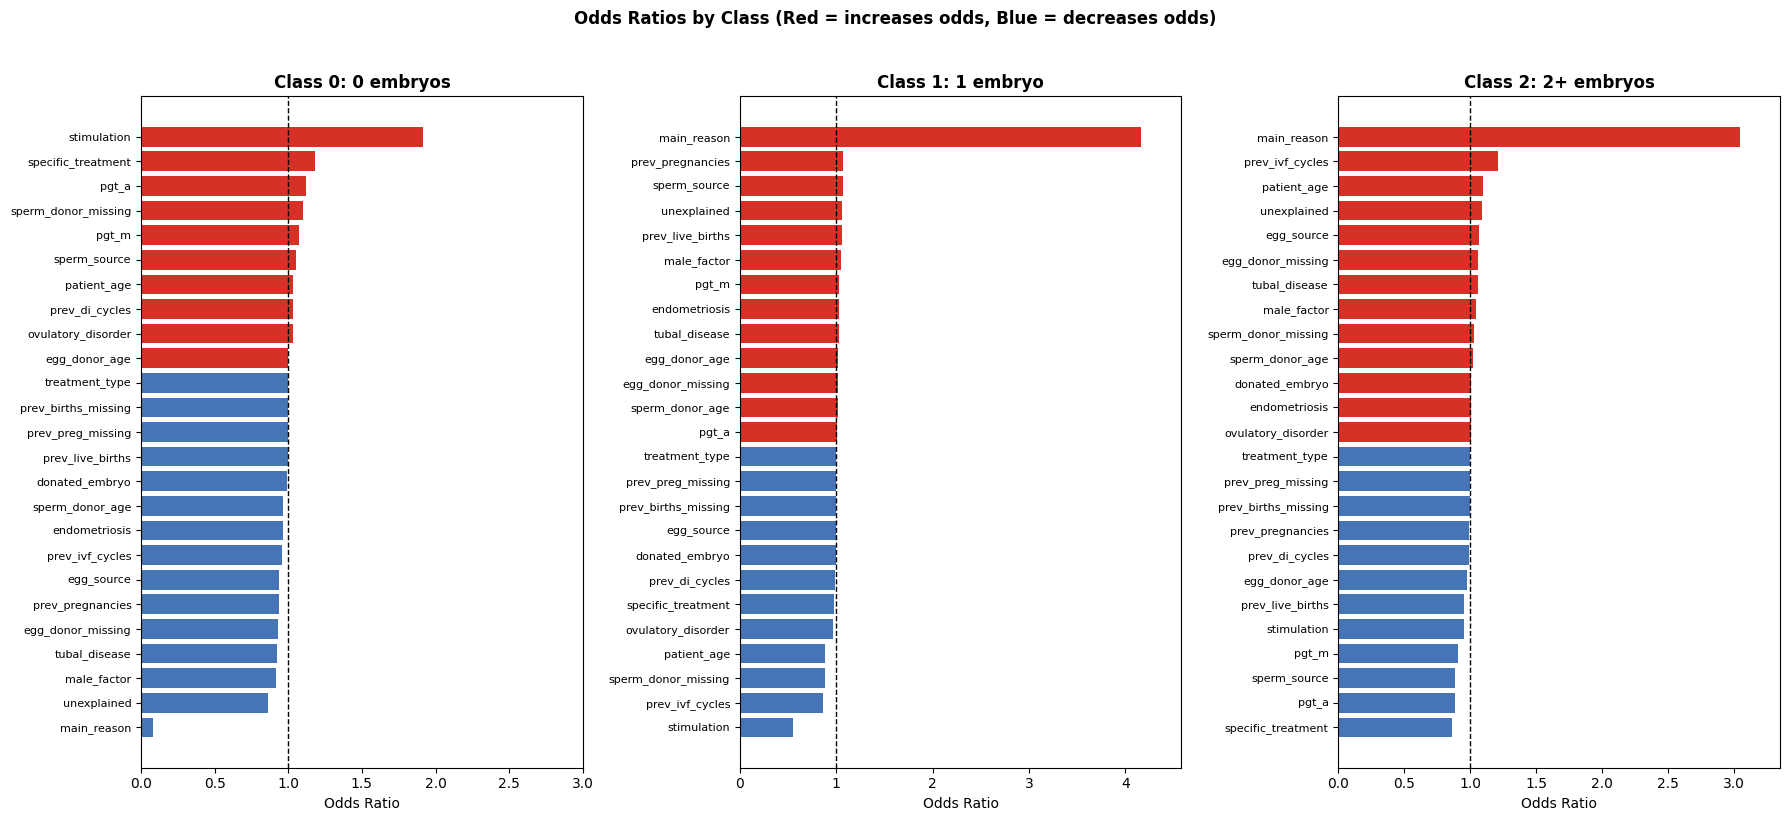

In [25]:
# ============================================================
# VISUALIZE ODDS RATIOS
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 8))

for i, (ax, class_name) in enumerate(zip(axes, class_names)):
    coefs = log_reg.coef_[i]
    odds_ratios = np.exp(coefs)
    
    or_df = pd.DataFrame({
        'Feature': short_feature_names,
        'Odds_Ratio': odds_ratios
    }).sort_values('Odds_Ratio', ascending=True)
    
    # Color bars based on OR
    colors = ['#d73027' if or_ > 1 else '#4575b4' for or_ in or_df['Odds_Ratio']]
    
    ax.barh(range(len(or_df)), or_df['Odds_Ratio'], color=colors)
    ax.set_yticks(range(len(or_df)))
    ax.set_yticklabels(or_df['Feature'], fontsize=8)
    ax.axvline(x=1, color='black', linestyle='--', linewidth=1)
    ax.set_xlabel('Odds Ratio')
    ax.set_title(f'Class {i}: {class_name}', fontweight='bold')
    ax.set_xlim(0, max(3, or_df['Odds_Ratio'].max() * 1.1))

plt.suptitle('Odds Ratios by Class (Red = increases odds, Blue = decreases odds)', 
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [37]:
# ============================================================
# PREDICT EMBRYOS CREATED (CLASSIFICATION APPROACH)
# ============================================================
# Since data is already in categories, treat as multi-class classification

print("="*70)
print("EMBRYOS CREATED - CLASSIFICATION MODEL")
print("="*70)

# Create categorical target from original ranges
# Note: After filtering out ESET and 0-transfer cases, we may not have "0 embryos" class
embryo_class_mapping = {
    '0': 0,        # No embryos (may be filtered out)
    '1-5': 1,      # Low yield
    '6-10': 2,     # Medium yield
    '11-15': 3,    # High yield
    '16-20': 3,    # High yield (combine)
    '21-25': 3,    # High yield
    '26-30': 3,    # High yield
    '>30': 3       # High yield
}

# Create classification target
embryo_df = model_df.copy()
embryo_df['embryo_class'] = df2.loc[model_df.index, 'total_embryos_created'].map(embryo_class_mapping)
embryo_df = embryo_df.dropna(subset=['embryo_class'])
embryo_df['embryo_class'] = embryo_df['embryo_class'].astype(int)

# Check which classes actually exist
unique_classes = sorted(embryo_df['embryo_class'].unique())
print(f"\nClasses present in data: {unique_classes}")

# Create dynamic class names based on what's in the data
all_class_names = {0: 'None (0)', 1: 'Low (1-5)', 2: 'Medium (6-10)', 3: 'High (11+)'}
embryo_class_names = [all_class_names[c] for c in unique_classes]

# Remap to consecutive integers if needed
if unique_classes != list(range(len(unique_classes))):
    remap = {old: new for new, old in enumerate(unique_classes)}
    embryo_df['embryo_class'] = embryo_df['embryo_class'].map(remap)
    print(f"Remapped classes to: {list(range(len(unique_classes)))}")

print(f"\nDataset size: {len(embryo_df):,}")
print(f"\nClass distribution:")
for i, name in enumerate(embryo_class_names):
    count = (embryo_df['embryo_class'] == i).sum()
    pct = count / len(embryo_df) * 100
    print(f"  {i} - {name}: {count:,} ({pct:.1f}%)")

EMBRYOS CREATED - CLASSIFICATION MODEL

Classes present in data: [np.int64(1), np.int64(2), np.int64(3)]
Remapped classes to: [0, 1, 2]

Dataset size: 58,702

Class distribution:
  0 - Low (1-5): 34,650 (59.0%)
  1 - Medium (6-10): 15,992 (27.2%)
  2 - High (11+): 8,060 (13.7%)


In [38]:
# ============================================================
# PREPARE FEATURES FOR EMBRYOS CREATED PREDICTION
# ============================================================

# Use features available BEFORE embryo creation (exclude transfer-related)
pre_creation_features = [
    'patient_age_at_treatment',
    'total_number_of_previous_ivf_cycles',
    'total_number_of_previous_di_cycles',
    'total_number_of_previous_pregnancies_-_ivf_and_di',
    'total_number_of_previous_live_births_-_ivf_or_di',
    'causes_of_infertility_-_tubal_disease',
    'causes_of_infertility_-_ovulatory_disorder',
    'causes_of_infertility_-_male_factor',
    'causes_of_infertility_-_patient_unexplained',
    'causes_of_infertility_-_endometriosis',
    'stimulation_used',
    'egg_donor_age_at_registration',
    'sperm_donor_age_at_registration',
    'donated_embryo',
    'type_of_treatment_-_ivf_or_di',
    'specific_treatment_type',
    'egg_source',
    'sperm_source',
    'prev_pregnancies_missing',
    'prev_live_births_missing',
    'egg_donor_age_missing',
    'sperm_donor_age_missing'
]

X_emb = embryo_df[pre_creation_features]
y_emb = embryo_df['embryo_class']

X_emb_train, X_emb_test, y_emb_train, y_emb_test = train_test_split(
    X_emb, y_emb, test_size=0.2, random_state=42, stratify=y_emb
)

print(f"Train: {len(X_emb_train):,}, Test: {len(X_emb_test):,}")

Train: 46,961, Test: 11,741


In [39]:
# ============================================================
# TRAIN EMBRYOS CREATED CLASSIFIER
# ============================================================
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Train classifier
emb_clf = LGBMClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

print("Training LightGBM classifier for embryo yield...")
emb_clf.fit(X_emb_train, y_emb_train)

# Evaluate
y_emb_pred = emb_clf.predict(X_emb_test)

print("="*70)
print("EMBRYOS CREATED - CLASSIFICATION RESULTS")
print("="*70)
print("\nClassification Report:")
print(classification_report(y_emb_test, y_emb_pred, target_names=embryo_class_names))

print("Confusion Matrix:")
print(confusion_matrix(y_emb_test, y_emb_pred))

Training LightGBM classifier for embryo yield...
EMBRYOS CREATED - CLASSIFICATION RESULTS

Classification Report:
               precision    recall  f1-score   support

    Low (1-5)       0.60      0.96      0.74      6930
Medium (6-10)       0.34      0.04      0.06      3199
   High (11+)       0.39      0.08      0.13      1612

     accuracy                           0.59     11741
    macro avg       0.44      0.36      0.31     11741
 weighted avg       0.50      0.59      0.47     11741

Confusion Matrix:
[[6662  160  108]
 [2987  114   98]
 [1421   61  130]]


TOP PREDICTORS OF EMBRYO YIELD

Higher feature value → More embryos (↑) or Fewer embryos (↓)
------------------------------------------------------------
  prev_ivf_cycles                 2796  ↓ Fewer
  patient_age                     2478  ↓ Fewer
  sperm_donor_age                 1613  — Neutral
  specific_treatment              1548  ↑ More
  prev_di_cycles                  1185  — Neutral
  prev_pregnancies                 981  — Neutral
  egg_donor_age                    970  — Neutral
  male_factor                      721  ↓ Fewer
  prev_live_births                 645  — Neutral
  unexplained                      415  — Neutral


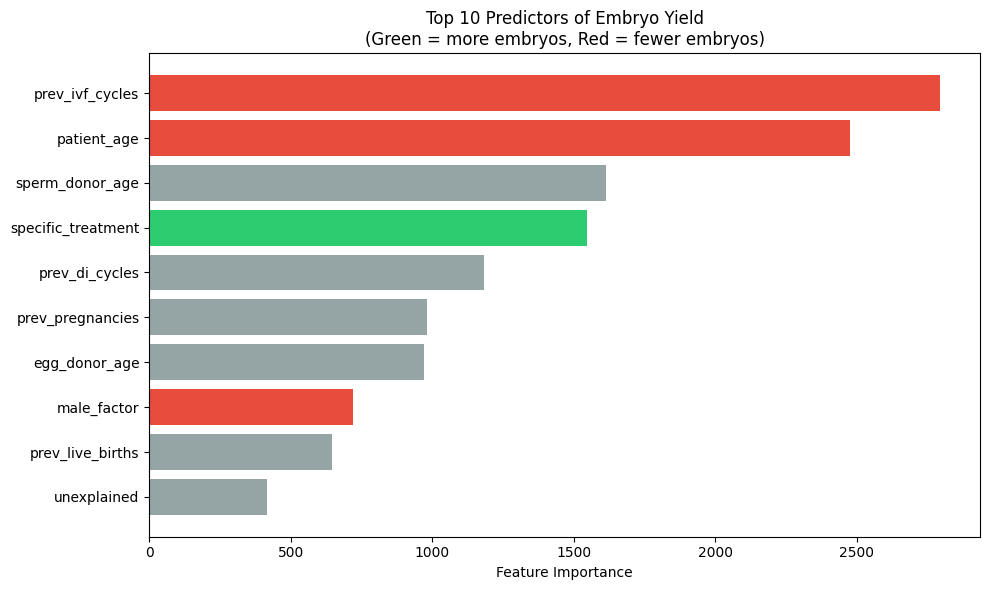

In [40]:
# ============================================================
# EMBRYOS CREATED - FEATURE IMPORTANCE
# ============================================================

emb_importance = pd.DataFrame({
    'feature': pre_creation_features,
    'importance': emb_clf.feature_importances_
}).sort_values('importance', ascending=False)

# Get direction from correlation with "high yield" (classes 2 or 3)
high_yield = (y_emb >= 2).astype(int)
correlations = X_emb.corrwith(high_yield)

print("="*70)
print("TOP PREDICTORS OF EMBRYO YIELD")
print("="*70)
print("\nHigher feature value → More embryos (↑) or Fewer embryos (↓)")
print("-"*60)

for _, row in emb_importance.head(10).iterrows():
    corr = correlations.get(row['feature'], 0)
    direction = '↑ More' if corr > 0.01 else ('↓ Fewer' if corr < -0.01 else '— Neutral')
    short = short_names.get(row['feature'], row['feature'])
    print(f"  {short:30} {row['importance']:>5.0f}  {direction}")

# Visualize
fig, ax = plt.subplots(figsize=(10, 6))
top_10 = emb_importance.head(10)
colors = ['#2ecc71' if correlations.get(f, 0) > 0.01 else '#e74c3c' if correlations.get(f, 0) < -0.01 else '#95a5a6' 
          for f in top_10['feature']]
ax.barh(range(len(top_10)), top_10['importance'].values, color=colors)
ax.set_yticks(range(len(top_10)))
ax.set_yticklabels([short_names.get(f, f) for f in top_10['feature'].values])
ax.invert_yaxis()
ax.set_xlabel('Feature Importance')
ax.set_title('Top 10 Predictors of Embryo Yield\n(Green = more embryos, Red = fewer embryos)')
plt.tight_layout()
plt.show()

SHAP VALUES: EMBRYO YIELD (ALL ELSE EQUAL)

These show the INDEPENDENT effect of each feature,
holding all other features constant.

Predicting: High (11+) (high embryo yield)
----------------------------------------------------------------------


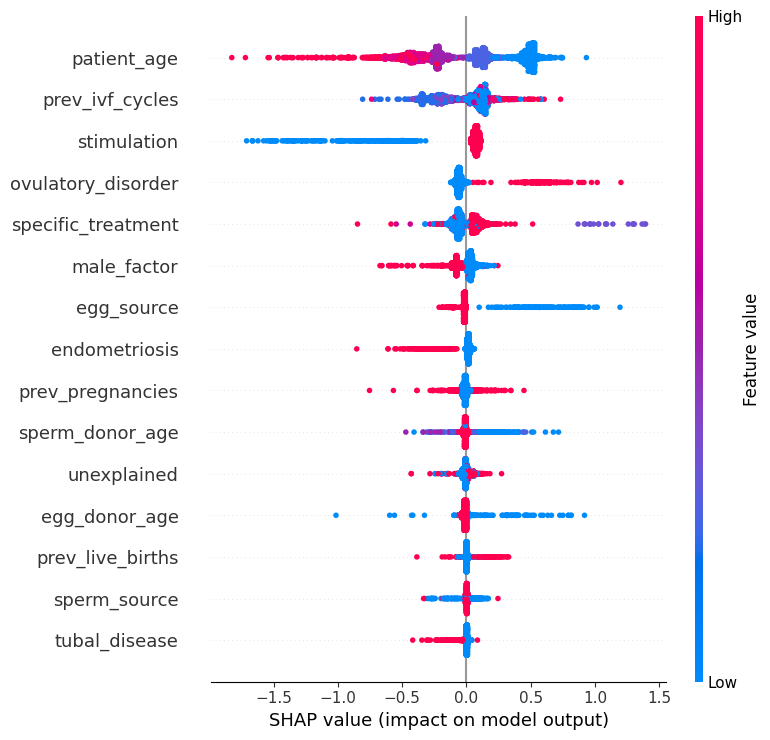

In [45]:
# ============================================================
# SHAP VALUES FOR EMBRYO YIELD MODEL (ALL ELSE EQUAL)
# ============================================================
import shap

# Create SHAP explainer for embryo classifier
emb_explainer = shap.TreeExplainer(emb_clf)

# Calculate SHAP values for test set sample
sample_size = min(3000, len(X_emb_test))
X_emb_sample = X_emb_test.sample(n=sample_size, random_state=42)
emb_shap_values = emb_explainer.shap_values(X_emb_sample)

# Short names for display
emb_short_names = [short_names.get(f, f) for f in pre_creation_features]

print("="*70)
print("SHAP VALUES: EMBRYO YIELD (ALL ELSE EQUAL)")
print("="*70)
print("\nThese show the INDEPENDENT effect of each feature,")
print("holding all other features constant.\n")

# Plot for the "High yield" class (class 2 after remapping, which is 11+ embryos)
# Or if 3 classes: class 2 is High (11+)
high_class_idx = len(embryo_class_names) - 1  # Last class = highest yield

print(f"Predicting: {embryo_class_names[high_class_idx]} (high embryo yield)")
print("-"*70)

if isinstance(emb_shap_values, list):
    shap_for_high = emb_shap_values[high_class_idx]
else:
    shap_for_high = emb_shap_values[:, :, high_class_idx]

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_for_high, X_emb_sample, feature_names=emb_short_names, max_display=15)
plt.show()

In [41]:
# ============================================================
# RISK SCORE: CYCLE CANCELLATION (0 EMBRYOS TRANSFERRED)
# ============================================================

# Create binary target: 1 = cycle cancelled (0 embryos transferred), 0 = transfer occurred
model_df['cycle_cancelled'] = (model_df['target'] == 0).astype(int)

print("="*70)
print("CYCLE CANCELLATION RISK MODEL")
print("="*70)
print(f"\nTarget distribution:")
print(f"  Cancelled (0 embryos): {model_df['cycle_cancelled'].sum():,} ({model_df['cycle_cancelled'].mean()*100:.1f}%)")
print(f"  Transfer occurred:     {(1-model_df['cycle_cancelled']).sum():,} ({(1-model_df['cycle_cancelled'].mean())*100:.1f}%)")

# Prepare data
X_risk = model_df[final_features]
y_risk = model_df['cycle_cancelled']

X_risk_train, X_risk_test, y_risk_train, y_risk_test = train_test_split(
    X_risk, y_risk, test_size=0.2, random_state=42, stratify=y_risk
)

# Train model
from lightgbm import LGBMClassifier

risk_model = LGBMClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

risk_model.fit(X_risk_train, y_risk_train)

# Get probabilities (risk scores)
risk_scores = risk_model.predict_proba(X_risk_test)[:, 1]

print(f"\nRisk Score Distribution:")
print(f"  Min:    {risk_scores.min():.3f}")
print(f"  Median: {np.median(risk_scores):.3f}")
print(f"  Max:    {risk_scores.max():.3f}")

CYCLE CANCELLATION RISK MODEL

Target distribution:
  Cancelled (0 embryos): 37,499 (35.7%)
  Transfer occurred:     67,650 (64.3%)

Risk Score Distribution:
  Min:    0.001
  Median: 0.220
  Max:    1.000


RISK MODEL PERFORMANCE

AUC-ROC:              0.8950
Average Precision:    0.8744

Classification Report:
              precision    recall  f1-score   support

 Transfer OK       0.83      0.97      0.89     13530
   Cancelled       0.92      0.64      0.75      7500

    accuracy                           0.85     21030
   macro avg       0.87      0.80      0.82     21030
weighted avg       0.86      0.85      0.84     21030



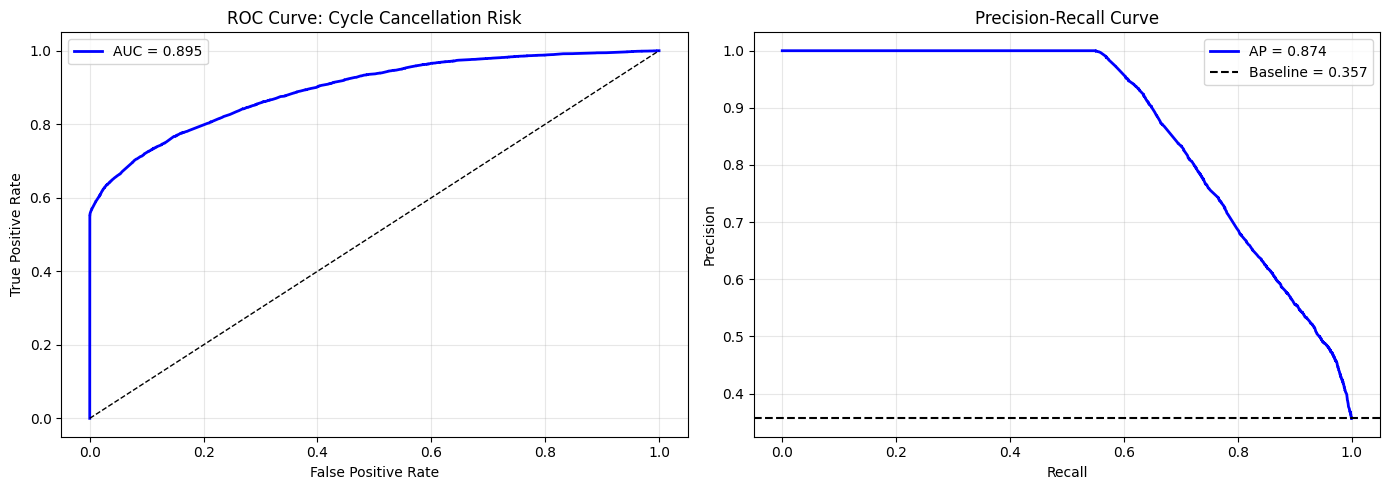

In [42]:
# ============================================================
# EVALUATE RISK SCORE MODEL
# ============================================================
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve, average_precision_score

# Calculate metrics
y_risk_pred = risk_model.predict(X_risk_test)
auc_score = roc_auc_score(y_risk_test, risk_scores)
ap_score = average_precision_score(y_risk_test, risk_scores)

print("="*70)
print("RISK MODEL PERFORMANCE")
print("="*70)
print(f"\nAUC-ROC:              {auc_score:.4f}")
print(f"Average Precision:    {ap_score:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_risk_test, y_risk_pred, target_names=['Transfer OK', 'Cancelled']))

# Plot ROC and PR curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curve
fpr, tpr, _ = roc_curve(y_risk_test, risk_scores)
axes[0].plot(fpr, tpr, 'b-', linewidth=2, label=f'AUC = {auc_score:.3f}')
axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve: Cycle Cancellation Risk')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_risk_test, risk_scores)
axes[1].plot(recall, precision, 'b-', linewidth=2, label=f'AP = {ap_score:.3f}')
axes[1].axhline(y=y_risk_test.mean(), color='k', linestyle='--', label=f'Baseline = {y_risk_test.mean():.3f}')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

RISK STRATIFICATION

Cancellation Rate by Risk Tier:
--------------------------------------------------
                  N_Patients  N_Cancelled Cancellation_Rate
risk_tier                                                  
Low (<15%)              7611          515              6.8%
Medium (15-25%)         3686          730             19.8%
High (25-40%)           3115          892             28.6%
Very High (>40%)        6618         5363             81.0%


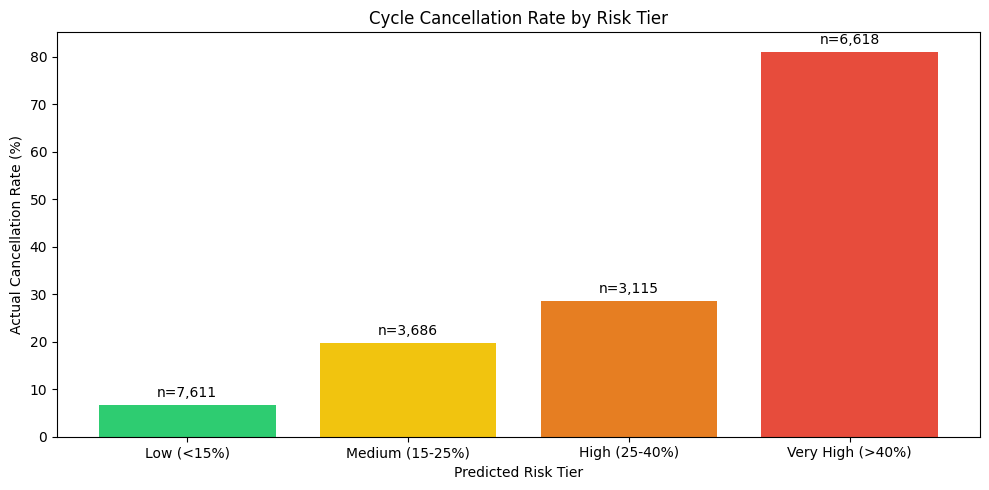

In [43]:
# ============================================================
# RISK STRATIFICATION
# ============================================================

# Create risk groups
risk_df = pd.DataFrame({
    'actual': y_risk_test.values,
    'risk_score': risk_scores
})

# Define risk tiers
risk_df['risk_tier'] = pd.cut(risk_df['risk_score'], 
                               bins=[0, 0.15, 0.25, 0.40, 1.0],
                               labels=['Low (<15%)', 'Medium (15-25%)', 'High (25-40%)', 'Very High (>40%)'])

print("="*70)
print("RISK STRATIFICATION")
print("="*70)
print("\nCancellation Rate by Risk Tier:")
print("-"*50)

tier_summary = risk_df.groupby('risk_tier').agg({
    'actual': ['count', 'sum', 'mean']
}).round(3)
tier_summary.columns = ['N_Patients', 'N_Cancelled', 'Cancellation_Rate']
tier_summary['Cancellation_Rate'] = (tier_summary['Cancellation_Rate'] * 100).round(1).astype(str) + '%'
print(tier_summary)

# Visualize
fig, ax = plt.subplots(figsize=(10, 5))
tier_rates = risk_df.groupby('risk_tier')['actual'].mean() * 100
tier_counts = risk_df.groupby('risk_tier')['actual'].count()

bars = ax.bar(range(len(tier_rates)), tier_rates.values, color=['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c'])
ax.set_xticks(range(len(tier_rates)))
ax.set_xticklabels(tier_rates.index, rotation=0)
ax.set_ylabel('Actual Cancellation Rate (%)')
ax.set_xlabel('Predicted Risk Tier')
ax.set_title('Cycle Cancellation Rate by Risk Tier')

# Add count labels
for i, (bar, count) in enumerate(zip(bars, tier_counts.values)):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
            f'n={count:,}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

TOP RISK FACTORS FOR CYCLE CANCELLATION

Top 15 Features:
  prev_ivf_cycles                   887
  patient_age                       857
  specific_treatment                559
  sperm_donor_age                   418
  egg_donor_age                     343
  male_factor                       341
  prev_di_cycles                    333
  prev_pregnancies                  307
  main_reason                       263
  prev_live_births                  243
  unexplained                       235
  stimulation                       223
  ovulatory_disorder                170
  endometriosis                     157
  pgt_a                             141


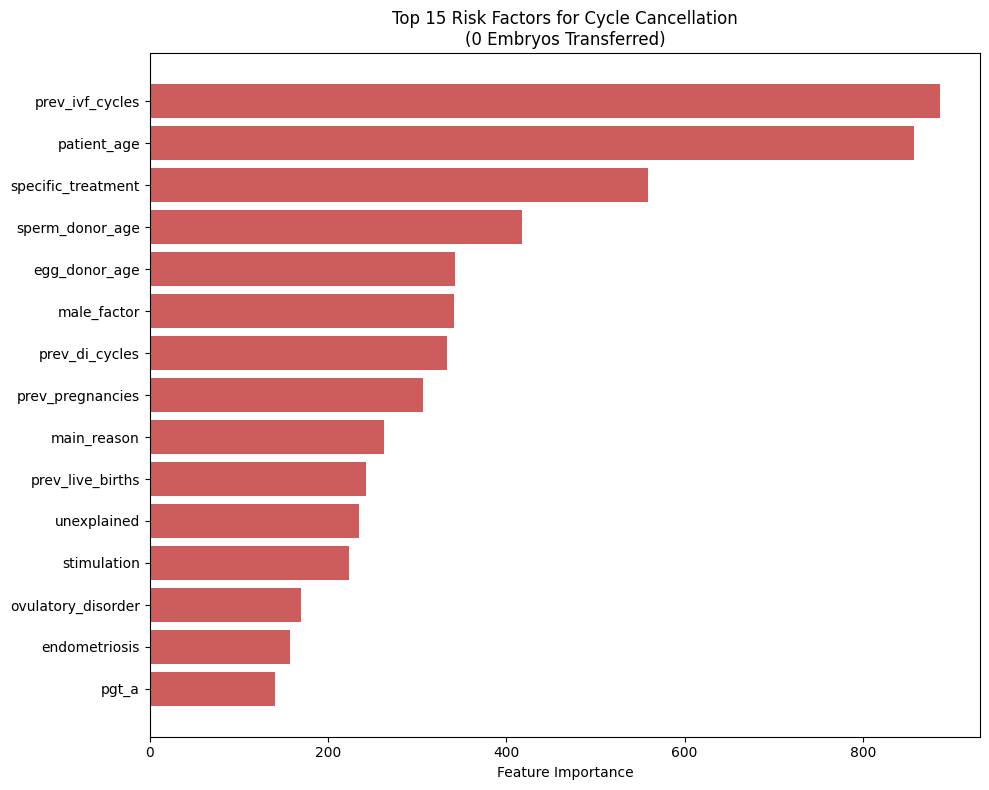

In [44]:
# ============================================================
# KEY RISK FACTORS FOR CYCLE CANCELLATION
# ============================================================

# Feature importance for risk model
risk_importance = pd.DataFrame({
    'feature': final_features,
    'importance': risk_model.feature_importances_
}).sort_values('importance', ascending=False)

print("="*70)
print("TOP RISK FACTORS FOR CYCLE CANCELLATION")
print("="*70)
print("\nTop 15 Features:")
for i, row in risk_importance.head(15).iterrows():
    short = short_names.get(row['feature'], row['feature'])
    print(f"  {short:30} {row['importance']:>6.0f}")

# Plot
fig, ax = plt.subplots(figsize=(10, 8))
top_15 = risk_importance.head(15)
ax.barh(range(len(top_15)), top_15['importance'].values, color='indianred')
ax.set_yticks(range(len(top_15)))
ax.set_yticklabels([short_names.get(f, f) for f in top_15['feature'].values])
ax.invert_yaxis()
ax.set_xlabel('Feature Importance')
ax.set_title('Top 15 Risk Factors for Cycle Cancellation\n(0 Embryos Transferred)')
plt.tight_layout()
plt.show()

# Summary of Models

## 1. Embryos Transferred Classification (3-class)
- **Model**: LightGBM Classifier
- **Target**: 0, 1, or 2+ embryos transferred
- **Use case**: Understanding factors driving transfer decisions

## 2. Logistic Regression with Odds Ratios
- **Model**: Multinomial Logistic Regression
- **Output**: Odds ratios for clinical interpretability
- **Use case**: Communicating results to clinicians

## 3. Embryos Created Prediction (Regression)
- **Model**: LightGBM Regressor
- **Target**: Number of embryos created
- **Use case**: Setting patient expectations, resource planning

## 4. Cycle Cancellation Risk Score
- **Model**: LightGBM Classifier (binary)
- **Target**: 0 = transfer occurred, 1 = cancelled (0 embryos transferred)
- **Output**: Probability score (0-100%)
- **Use case**: Identifying high-risk patients for counseling, intervention

---

### Clinical Applications:
1. **Pre-treatment counseling**: Use risk score to set realistic expectations
2. **Resource allocation**: Predict embryo yield for lab planning
3. **Quality improvement**: Identify modifiable risk factors
4. **Patient stratification**: Target interventions to high-risk groups

In [46]:
# ============================================================
# LIVE BIRTH PREDICTION MODEL
# ============================================================
# Binary classification: 1 = live birth, 0 = no live birth
# Including ESET and embryos transferred as predictors

print("="*70)
print("LIVE BIRTH PREDICTION MODEL")
print("="*70)

# Create fresh dataframe from df2 (not filtered for ESET)
live_birth_df = df2.copy()

# Check target distribution
print("\nLive birth occurrence distribution:")
print(live_birth_df['live_birth_occurrence'].value_counts(dropna=False))

# Define features for live birth prediction
# Include ESET and embryos transferred since these are known before outcome
live_birth_features = [
    'patient_age_at_treatment',
    'total_number_of_previous_ivf_cycles',
    'total_number_of_previous_di_cycles',
    'total_number_of_previous_pregnancies_-_ivf_and_di',
    'total_number_of_previous_live_births_-_ivf_or_di',
    'causes_of_infertility_-_tubal_disease',
    'causes_of_infertility_-_ovulatory_disorder',
    'causes_of_infertility_-_male_factor',
    'causes_of_infertility_-_patient_unexplained',
    'causes_of_infertility_-_endometriosis',
    'main_reason_for_producing_embroys_storing_eggs',
    'stimulation_used',
    'egg_donor_age_at_registration',
    'sperm_donor_age_at_registration',
    'donated_embryo',
    'type_of_treatment_-_ivf_or_di',
    'specific_treatment_type',
    'pgt-m_treatment',
    'pgt-a_treatment',
    'elective_single_embryo_transfer',  # INCLUDED for this model
    'egg_source',
    'sperm_source',
    'embryos_transferred',              # INCLUDED - key predictor
    'total_embryos_created'             # INCLUDED - intermediate outcome
]

# Create working dataframe
lb_df = live_birth_df[live_birth_features + ['live_birth_occurrence']].copy()

# Drop rows with missing target
lb_df = lb_df.dropna(subset=['live_birth_occurrence'])
lb_df['live_birth'] = lb_df['live_birth_occurrence'].astype(int)

print(f"\nDataset size after dropping missing target: {len(lb_df):,}")
print(f"\nLive birth rate: {lb_df['live_birth'].mean()*100:.1f}%")

LIVE BIRTH PREDICTION MODEL

Live birth occurrence distribution:
live_birth_occurrence
0    128593
1     41023
Name: count, dtype: int64

Dataset size after dropping missing target: 169,616

Live birth rate: 24.2%


In [47]:
# ============================================================
# PREPARE LIVE BIRTH DATA
# ============================================================

# Handle missing values
lb_df['prev_pregnancies_missing'] = lb_df['total_number_of_previous_pregnancies_-_ivf_and_di'].isnull().astype(int)
lb_df['prev_live_births_missing'] = lb_df['total_number_of_previous_live_births_-_ivf_or_di'].isnull().astype(int)
lb_df['egg_donor_age_missing'] = lb_df['egg_donor_age_at_registration'].isnull().astype(int)
lb_df['sperm_donor_age_missing'] = lb_df['sperm_donor_age_at_registration'].isnull().astype(int)
lb_df['eset_missing'] = lb_df['elective_single_embryo_transfer'].isnull().astype(int)
lb_df['embryos_transferred_missing'] = lb_df['embryos_transferred'].isnull().astype(int)
lb_df['embryos_created_missing'] = lb_df['total_embryos_created'].isnull().astype(int)

# Fill nulls
lb_df['total_number_of_previous_pregnancies_-_ivf_and_di'] = lb_df['total_number_of_previous_pregnancies_-_ivf_and_di'].fillna(0)
lb_df['total_number_of_previous_live_births_-_ivf_or_di'] = lb_df['total_number_of_previous_live_births_-_ivf_or_di'].fillna('0')
lb_df['donated_embryo'] = lb_df['donated_embryo'].fillna(0)
lb_df['elective_single_embryo_transfer'] = lb_df['elective_single_embryo_transfer'].fillna(0)
lb_df['embryos_transferred'] = lb_df['embryos_transferred'].fillna(0)

# Handle categorical columns
lb_df['patient_age_at_treatment'] = lb_df['patient_age_at_treatment'].replace('999', 'Unknown')
lb_df['egg_donor_age_at_registration'] = lb_df['egg_donor_age_at_registration'].fillna('Not_Donor')
lb_df['sperm_donor_age_at_registration'] = lb_df['sperm_donor_age_at_registration'].fillna('Not_Donor')
lb_df['main_reason_for_producing_embroys_storing_eggs'] = lb_df['main_reason_for_producing_embroys_storing_eggs'].fillna('Unknown')
lb_df['egg_source'] = lb_df['egg_source'].fillna('Unknown')
lb_df['sperm_source'] = lb_df['sperm_source'].fillna('Unknown')

# Convert total_embryos_created to numeric (it's categorical ranges)
embryo_created_map = {'0': 0, '1-5': 3, '6-10': 8, '11-15': 13, '16-20': 18, '21-25': 23, '26-30': 28, '>30': 35}
lb_df['total_embryos_created'] = lb_df['total_embryos_created'].map(embryo_created_map).fillna(0)

print("Missing values after handling:")
print(lb_df.isnull().sum()[lb_df.isnull().sum() > 0])

Missing values after handling:
Series([], dtype: int64)


In [48]:
# ============================================================
# ENCODE CATEGORICAL VARIABLES FOR LIVE BIRTH MODEL
# ============================================================
from sklearn.preprocessing import LabelEncoder

lb_cat_cols = [
    'patient_age_at_treatment',
    'total_number_of_previous_ivf_cycles',
    'total_number_of_previous_di_cycles',
    'total_number_of_previous_live_births_-_ivf_or_di',
    'main_reason_for_producing_embroys_storing_eggs',
    'egg_donor_age_at_registration',
    'sperm_donor_age_at_registration',
    'type_of_treatment_-_ivf_or_di',
    'specific_treatment_type',
    'egg_source',
    'sperm_source'
]

lb_encoders = {}
for col in lb_cat_cols:
    le = LabelEncoder()
    lb_df[col] = le.fit_transform(lb_df[col].astype(str))
    lb_encoders[col] = le

print("Encoding complete. Data types:")
print(lb_df.dtypes)

Encoding complete. Data types:
patient_age_at_treatment                               int64
total_number_of_previous_ivf_cycles                    int64
total_number_of_previous_di_cycles                     int64
total_number_of_previous_pregnancies_-_ivf_and_di    float64
total_number_of_previous_live_births_-_ivf_or_di       int64
causes_of_infertility_-_tubal_disease                  int64
causes_of_infertility_-_ovulatory_disorder             int64
causes_of_infertility_-_male_factor                    int64
causes_of_infertility_-_patient_unexplained            int64
causes_of_infertility_-_endometriosis                  int64
main_reason_for_producing_embroys_storing_eggs         int64
stimulation_used                                       int64
egg_donor_age_at_registration                          int64
sperm_donor_age_at_registration                        int64
donated_embryo                                       float64
type_of_treatment_-_ivf_or_di                         

In [49]:
# ============================================================
# TRAIN LIVE BIRTH CLASSIFIER
# ============================================================
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, average_precision_score

# Final feature list
lb_final_features = live_birth_features + [
    'prev_pregnancies_missing',
    'prev_live_births_missing',
    'egg_donor_age_missing',
    'sperm_donor_age_missing',
    'eset_missing',
    'embryos_transferred_missing',
    'embryos_created_missing'
]

X_lb = lb_df[lb_final_features]
y_lb = lb_df['live_birth']

# Train/test split
X_lb_train, X_lb_test, y_lb_train, y_lb_test = train_test_split(
    X_lb, y_lb, test_size=0.2, random_state=42, stratify=y_lb
)

print(f"Training set: {len(X_lb_train):,}")
print(f"Test set: {len(X_lb_test):,}")
print(f"Live birth rate (train): {y_lb_train.mean()*100:.1f}%")

# Train model
lb_model = LGBMClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

print("\nTraining LightGBM classifier...")
lb_model.fit(X_lb_train, y_lb_train)
print("Training complete!")

Training set: 135,692
Test set: 33,924
Live birth rate (train): 24.2%

Training LightGBM classifier...
Training complete!


LIVE BIRTH MODEL - EVALUATION

AUC-ROC: 0.754
Average Precision: 0.423

Classification Report:
               precision    recall  f1-score   support

No Live Birth       0.76      0.98      0.86     25719
   Live Birth       0.47      0.05      0.09      8205

     accuracy                           0.76     33924
    macro avg       0.62      0.52      0.48     33924
 weighted avg       0.69      0.76      0.67     33924



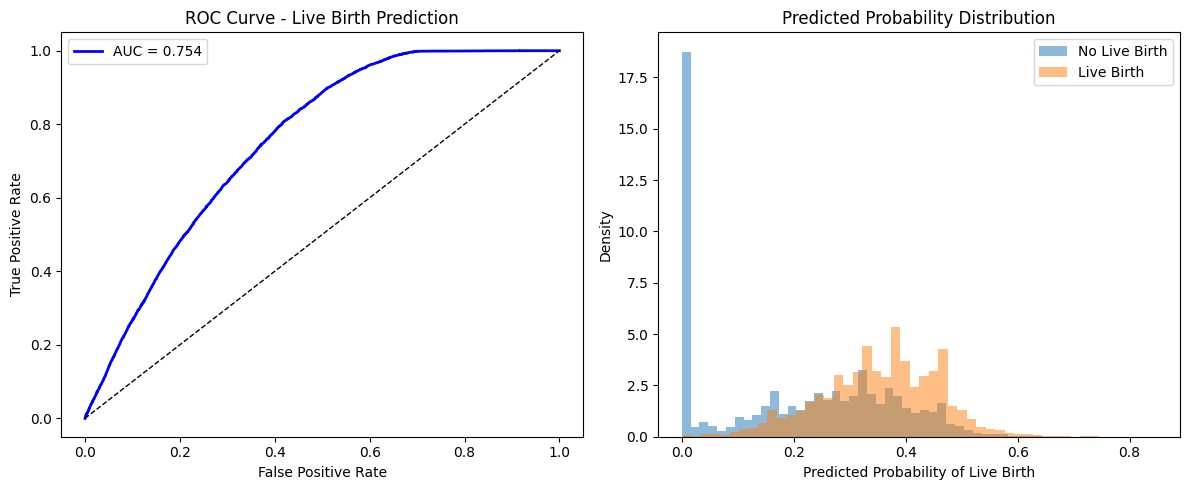

In [50]:
# ============================================================
# EVALUATE LIVE BIRTH MODEL
# ============================================================

# Predictions
y_lb_pred = lb_model.predict(X_lb_test)
y_lb_prob = lb_model.predict_proba(X_lb_test)[:, 1]

# Metrics
auc_roc = roc_auc_score(y_lb_test, y_lb_prob)
avg_precision = average_precision_score(y_lb_test, y_lb_prob)

print("="*70)
print("LIVE BIRTH MODEL - EVALUATION")
print("="*70)
print(f"\nAUC-ROC: {auc_roc:.3f}")
print(f"Average Precision: {avg_precision:.3f}")
print("\nClassification Report:")
print(classification_report(y_lb_test, y_lb_pred, target_names=['No Live Birth', 'Live Birth']))

# ROC Curve
fpr, tpr, _ = roc_curve(y_lb_test, y_lb_prob)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ROC
axes[0].plot(fpr, tpr, 'b-', linewidth=2, label=f'AUC = {auc_roc:.3f}')
axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve - Live Birth Prediction')
axes[0].legend()

# Predicted probability distribution
axes[1].hist(y_lb_prob[y_lb_test == 0], bins=50, alpha=0.5, label='No Live Birth', density=True)
axes[1].hist(y_lb_prob[y_lb_test == 1], bins=50, alpha=0.5, label='Live Birth', density=True)
axes[1].set_xlabel('Predicted Probability of Live Birth')
axes[1].set_ylabel('Density')
axes[1].set_title('Predicted Probability Distribution')
axes[1].legend()

plt.tight_layout()
plt.show()

TOP PREDICTORS OF LIVE BIRTH

Higher feature value → More likely (↑) or Less likely (↓) live birth
------------------------------------------------------------
  prev_ivf_cycles                  740  — Neutral
  patient_age                      718  ↓ Less
  embryos_created                  543  ↑ More
  sperm_donor_age                  471  ↑ More
  embryos_transferred              407  ↑ More
  specific_treatment               333  ↑ More
  prev_pregnancies                 318  ↑ More
  prev_live_births                 316  ↑ More
  egg_donor_age                    307  ↓ Less
  prev_di_cycles                   299  ↓ Less
  eset                             195  ↑ More
  male_factor                      194  ↑ More
  unexplained                      137  ↑ More
  stimulation                      127  ↓ Less
  ovulatory_disorder               126  ↑ More


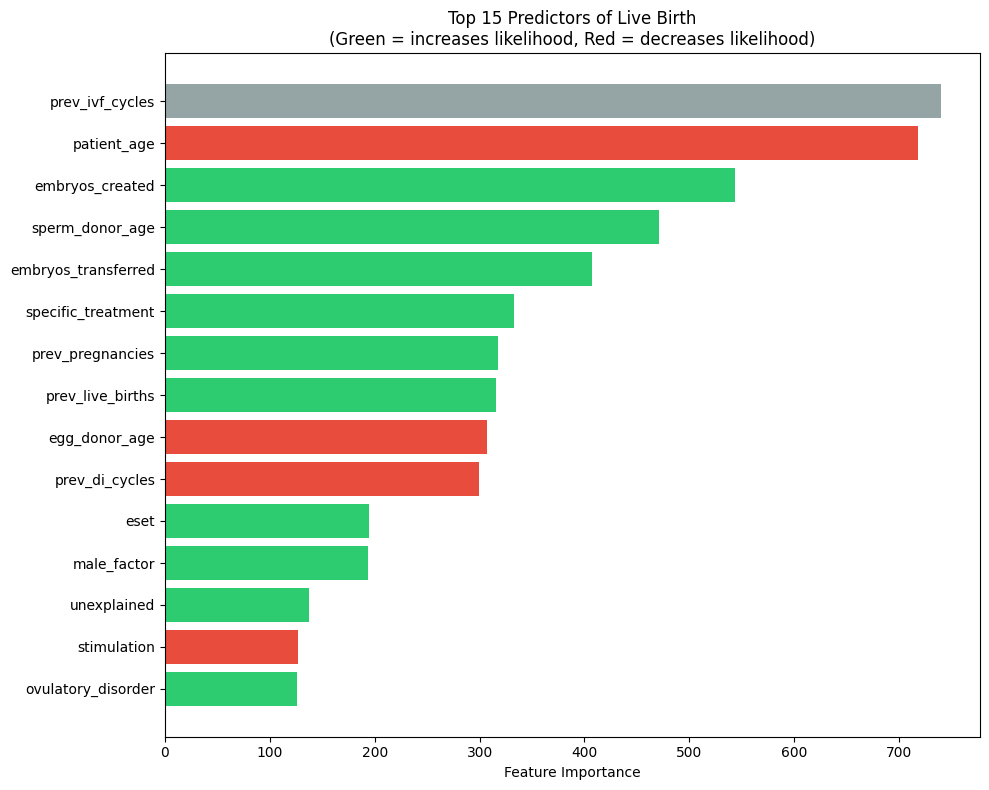

In [51]:
# ============================================================
# LIVE BIRTH - FEATURE IMPORTANCE
# ============================================================

# Short names for live birth model
lb_short_names = {
    'patient_age_at_treatment': 'patient_age',
    'total_number_of_previous_ivf_cycles': 'prev_ivf_cycles',
    'total_number_of_previous_di_cycles': 'prev_di_cycles',
    'total_number_of_previous_pregnancies_-_ivf_and_di': 'prev_pregnancies',
    'total_number_of_previous_live_births_-_ivf_or_di': 'prev_live_births',
    'causes_of_infertility_-_tubal_disease': 'tubal_disease',
    'causes_of_infertility_-_ovulatory_disorder': 'ovulatory_disorder',
    'causes_of_infertility_-_male_factor': 'male_factor',
    'causes_of_infertility_-_patient_unexplained': 'unexplained',
    'causes_of_infertility_-_endometriosis': 'endometriosis',
    'main_reason_for_producing_embroys_storing_eggs': 'main_reason',
    'stimulation_used': 'stimulation',
    'egg_donor_age_at_registration': 'egg_donor_age',
    'sperm_donor_age_at_registration': 'sperm_donor_age',
    'donated_embryo': 'donated_embryo',
    'type_of_treatment_-_ivf_or_di': 'treatment_type',
    'specific_treatment_type': 'specific_treatment',
    'pgt-m_treatment': 'pgt_m',
    'pgt-a_treatment': 'pgt_a',
    'elective_single_embryo_transfer': 'eset',
    'egg_source': 'egg_source',
    'sperm_source': 'sperm_source',
    'embryos_transferred': 'embryos_transferred',
    'total_embryos_created': 'embryos_created',
    'prev_pregnancies_missing': 'prev_preg_missing',
    'prev_live_births_missing': 'prev_births_missing',
    'egg_donor_age_missing': 'egg_donor_missing',
    'sperm_donor_age_missing': 'sperm_donor_missing',
    'eset_missing': 'eset_missing',
    'embryos_transferred_missing': 'emb_trans_missing',
    'embryos_created_missing': 'emb_created_missing'
}

lb_importance = pd.DataFrame({
    'feature': lb_final_features,
    'importance': lb_model.feature_importances_
}).sort_values('importance', ascending=False)

print("="*70)
print("TOP PREDICTORS OF LIVE BIRTH")
print("="*70)

# Get direction from correlation
lb_correlations = X_lb.corrwith(y_lb)

print("\nHigher feature value → More likely (↑) or Less likely (↓) live birth")
print("-"*60)

for _, row in lb_importance.head(15).iterrows():
    corr = lb_correlations.get(row['feature'], 0)
    direction = '↑ More' if corr > 0.01 else ('↓ Less' if corr < -0.01 else '— Neutral')
    short = lb_short_names.get(row['feature'], row['feature'])
    print(f"  {short:30} {row['importance']:>5.0f}  {direction}")

# Visualize
fig, ax = plt.subplots(figsize=(10, 8))
top_15 = lb_importance.head(15)
colors = ['#2ecc71' if lb_correlations.get(f, 0) > 0.01 else '#e74c3c' if lb_correlations.get(f, 0) < -0.01 else '#95a5a6' 
          for f in top_15['feature']]
ax.barh(range(len(top_15)), top_15['importance'].values, color=colors)
ax.set_yticks(range(len(top_15)))
ax.set_yticklabels([lb_short_names.get(f, f) for f in top_15['feature'].values])
ax.invert_yaxis()
ax.set_xlabel('Feature Importance')
ax.set_title('Top 15 Predictors of Live Birth\n(Green = increases likelihood, Red = decreases likelihood)')
plt.tight_layout()
plt.show()

SHAP VALUES: LIVE BIRTH (ALL ELSE EQUAL)

These show the INDEPENDENT effect of each feature,
holding all other features constant.



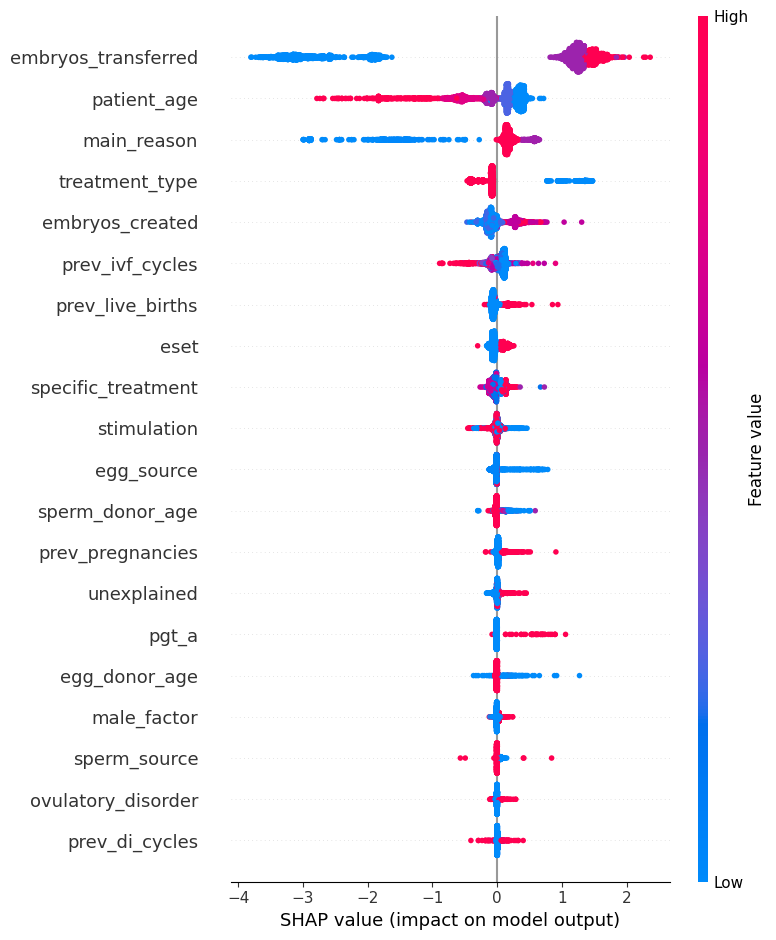

In [53]:
# ============================================================
# SHAP VALUES FOR LIVE BIRTH MODEL
# ============================================================
import shap

# Create SHAP explainer
lb_explainer = shap.TreeExplainer(lb_model)

# Calculate SHAP values for test set sample
lb_sample_size = min(3000, len(X_lb_test))
X_lb_sample = X_lb_test.sample(n=lb_sample_size, random_state=42)
lb_shap_values = lb_explainer.shap_values(X_lb_sample)

# Short names for display
lb_short_feature_names = [lb_short_names.get(f, f) for f in lb_final_features]

print("="*70)
print("SHAP VALUES: LIVE BIRTH (ALL ELSE EQUAL)")
print("="*70)
print("\nThese show the INDEPENDENT effect of each feature,")
print("holding all other features constant.\n")

# Handle different SHAP output formats for binary classification
if isinstance(lb_shap_values, list):
    shap_for_lb = lb_shap_values[1]  # Class 1 = Live Birth
elif lb_shap_values.ndim == 3:
    shap_for_lb = lb_shap_values[:, :, 1]
else:
    # 2D array - already for positive class (newer SHAP versions)
    shap_for_lb = lb_shap_values

plt.figure(figsize=(10, 10))
shap.summary_plot(shap_for_lb, X_lb_sample, feature_names=lb_short_feature_names, max_display=20)
plt.show()

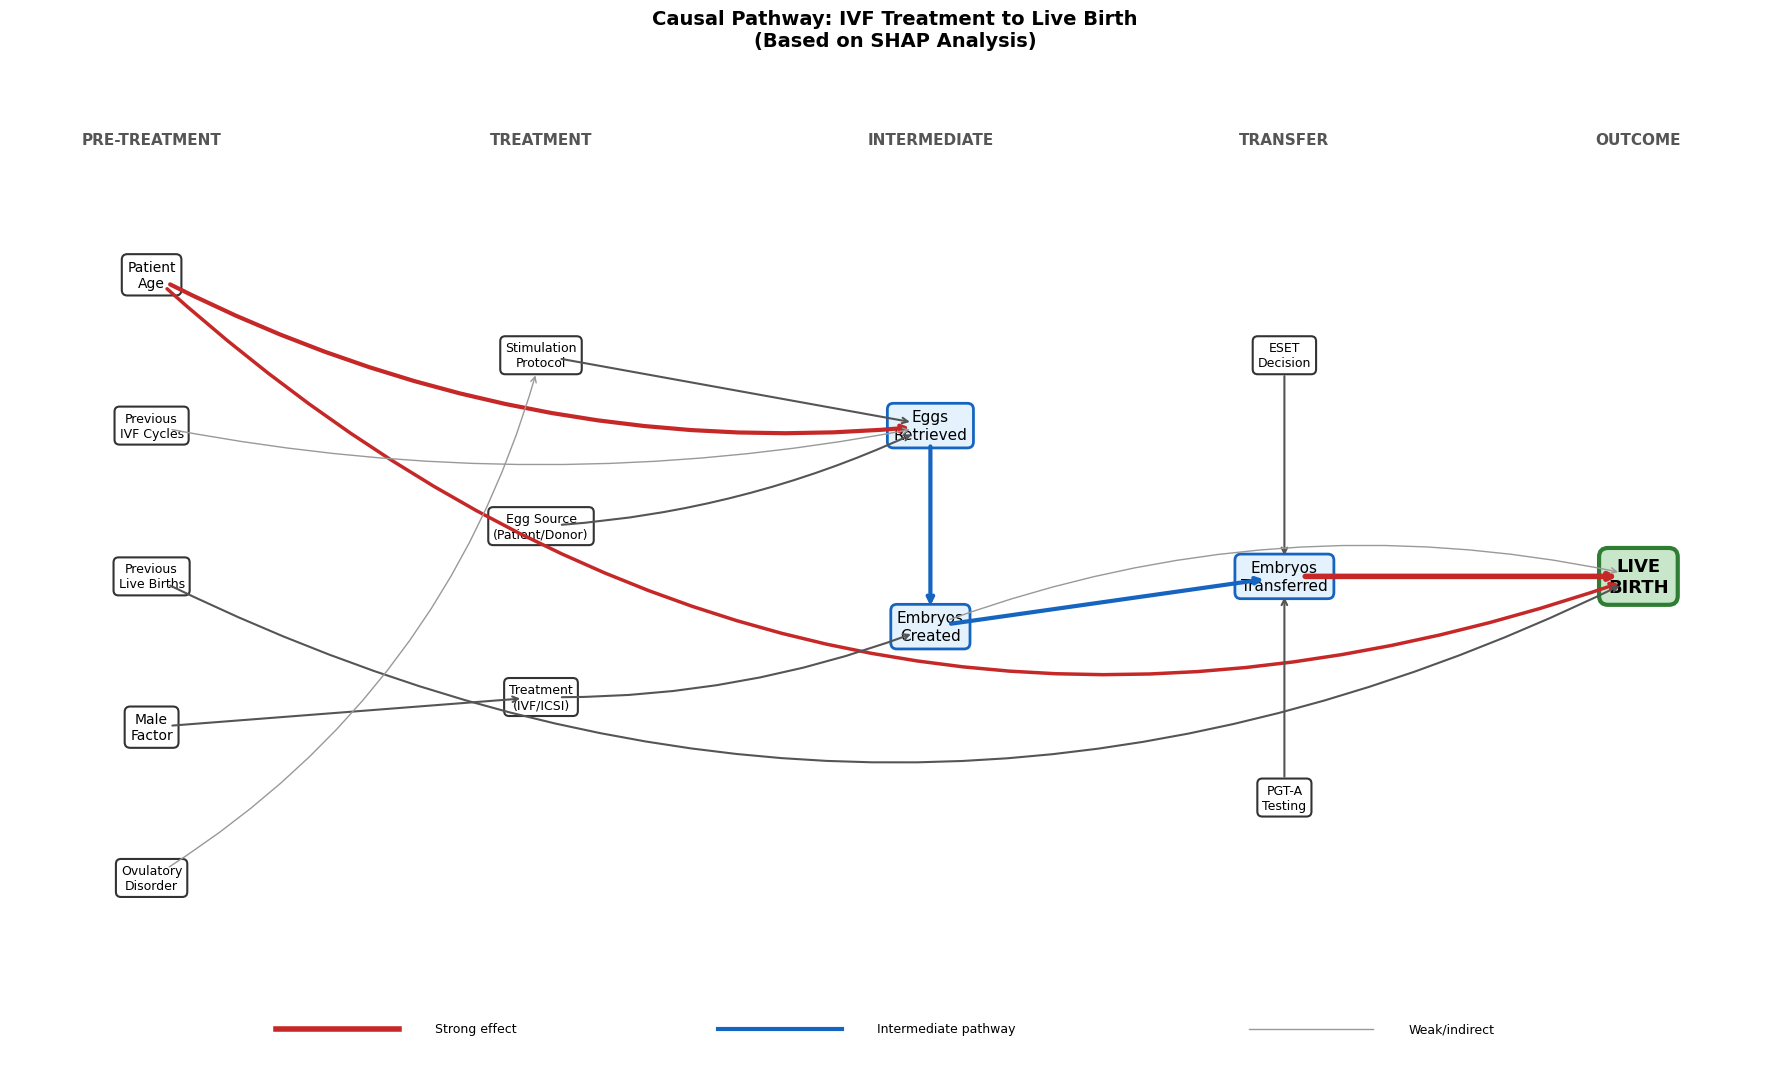

In [55]:
# ============================================================
# CAUSAL DIAGRAM: IVF PATHWAY TO LIVE BIRTH
# ============================================================
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, ax = plt.subplots(figsize=(18, 11))
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)
ax.axis('off')

# ============================================================
# DEFINE POSITIONS (x, y) for each node
# ============================================================
positions = {
    # Pre-treatment factors
    'age': (8, 80),
    'prev_cycles': (8, 65),
    'prev_births': (8, 50),
    'male_factor': (8, 35),
    'ovulatory': (8, 20),
    
    # Treatment decisions
    'stimulation': (30, 72),
    'egg_source': (30, 55),
    'treatment_type': (30, 38),
    
    # Intermediate outcomes
    'eggs': (52, 65),
    'embryos_created': (52, 45),
    
    # Transfer stage
    'eset': (72, 72),
    'embryos_transferred': (72, 50),
    'pgt_a': (72, 28),
    
    # Final outcome
    'live_birth': (92, 50),
}

# ============================================================
# DRAW BOXES
# ============================================================
box_style = dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='#333', linewidth=1.5)
intermediate_style = dict(boxstyle='round,pad=0.4', facecolor='#e3f2fd', edgecolor='#1565c0', linewidth=2)
outcome_style = dict(boxstyle='round,pad=0.5', facecolor='#c8e6c9', edgecolor='#2e7d32', linewidth=3)

# Pre-treatment
ax.text(*positions['age'], 'Patient\nAge', fontsize=10, ha='center', va='center', bbox=box_style)
ax.text(*positions['prev_cycles'], 'Previous\nIVF Cycles', fontsize=9, ha='center', va='center', bbox=box_style)
ax.text(*positions['prev_births'], 'Previous\nLive Births', fontsize=9, ha='center', va='center', bbox=box_style)
ax.text(*positions['male_factor'], 'Male\nFactor', fontsize=10, ha='center', va='center', bbox=box_style)
ax.text(*positions['ovulatory'], 'Ovulatory\nDisorder', fontsize=9, ha='center', va='center', bbox=box_style)

# Treatment
ax.text(*positions['stimulation'], 'Stimulation\nProtocol', fontsize=9, ha='center', va='center', bbox=box_style)
ax.text(*positions['egg_source'], 'Egg Source\n(Patient/Donor)', fontsize=9, ha='center', va='center', bbox=box_style)
ax.text(*positions['treatment_type'], 'Treatment\n(IVF/ICSI)', fontsize=9, ha='center', va='center', bbox=box_style)

# Intermediate
ax.text(*positions['eggs'], 'Eggs\nRetrieved', fontsize=11, ha='center', va='center', bbox=intermediate_style)
ax.text(*positions['embryos_created'], 'Embryos\nCreated', fontsize=11, ha='center', va='center', bbox=intermediate_style)

# Transfer
ax.text(*positions['eset'], 'ESET\nDecision', fontsize=9, ha='center', va='center', bbox=box_style)
ax.text(*positions['embryos_transferred'], 'Embryos\nTransferred', fontsize=11, ha='center', va='center', bbox=intermediate_style)
ax.text(*positions['pgt_a'], 'PGT-A\nTesting', fontsize=9, ha='center', va='center', bbox=box_style)

# Outcome
ax.text(*positions['live_birth'], 'LIVE\nBIRTH', fontsize=13, ha='center', va='center', fontweight='bold', bbox=outcome_style)

# ============================================================
# STAGE LABELS
# ============================================================
ax.text(8, 93, 'PRE-TREATMENT', fontsize=11, fontweight='bold', ha='center', color='#555')
ax.text(30, 93, 'TREATMENT', fontsize=11, fontweight='bold', ha='center', color='#555')
ax.text(52, 93, 'INTERMEDIATE', fontsize=11, fontweight='bold', ha='center', color='#555')
ax.text(72, 93, 'TRANSFER', fontsize=11, fontweight='bold', ha='center', color='#555')
ax.text(92, 93, 'OUTCOME', fontsize=11, fontweight='bold', ha='center', color='#555')

# ============================================================
# DRAW ARROWS
# ============================================================
def draw_arrow(start, end, color='#555', lw=1.5, style='arc3,rad=0.1'):
    ax.annotate('', xy=end, xytext=start,
                arrowprops=dict(arrowstyle='->', color=color, lw=lw, 
                               connectionstyle=style, shrinkA=15, shrinkB=15))

# Age → Eggs (STRONG - red)
draw_arrow(positions['age'], positions['eggs'], color='#c62828', lw=3, style='arc3,rad=0.15')

# Age → Live Birth (direct effect - strong)
draw_arrow(positions['age'], positions['live_birth'], color='#c62828', lw=2.5, style='arc3,rad=0.3')

# Previous cycles → Eggs (weak)
draw_arrow(positions['prev_cycles'], positions['eggs'], color='#999', lw=1, style='arc3,rad=0.1')

# Previous births → Live Birth (moderate)
draw_arrow(positions['prev_births'], positions['live_birth'], color='#555', lw=1.5, style='arc3,rad=0.25')

# Male factor → Treatment type
draw_arrow(positions['male_factor'], positions['treatment_type'], color='#555', lw=1.5, style='arc3,rad=0')

# Ovulatory → Stimulation
draw_arrow(positions['ovulatory'], positions['stimulation'], color='#999', lw=1, style='arc3,rad=0.2')

# Stimulation → Eggs
draw_arrow(positions['stimulation'], positions['eggs'], color='#555', lw=1.5, style='arc3,rad=0')

# Egg source → Eggs
draw_arrow(positions['egg_source'], positions['eggs'], color='#555', lw=1.5, style='arc3,rad=0.1')

# Treatment type → Embryos created
draw_arrow(positions['treatment_type'], positions['embryos_created'], color='#555', lw=1.5, style='arc3,rad=0.1')

# Eggs → Embryos created (STRONG - blue)
draw_arrow(positions['eggs'], positions['embryos_created'], color='#1565c0', lw=3, style='arc3,rad=0')

# Embryos created → Embryos transferred (STRONG - blue)
draw_arrow(positions['embryos_created'], positions['embryos_transferred'], color='#1565c0', lw=3, style='arc3,rad=0')

# ESET → Embryos transferred
draw_arrow(positions['eset'], positions['embryos_transferred'], color='#555', lw=1.5, style='arc3,rad=0')

# PGT-A → Embryos transferred
draw_arrow(positions['pgt_a'], positions['embryos_transferred'], color='#555', lw=1.5, style='arc3,rad=0')

# Embryos transferred → Live Birth (STRONGEST - red)
draw_arrow(positions['embryos_transferred'], positions['live_birth'], color='#c62828', lw=4, style='arc3,rad=0')

# Embryos created → Live Birth (weak direct)
draw_arrow(positions['embryos_created'], positions['live_birth'], color='#999', lw=1, style='arc3,rad=-0.15')

# ============================================================
# LEGEND
# ============================================================
ax.plot([15, 22], [5, 5], color='#c62828', lw=4)
ax.text(24, 5, 'Strong effect', fontsize=9, va='center')

ax.plot([40, 47], [5, 5], color='#1565c0', lw=3)
ax.text(49, 5, 'Intermediate pathway', fontsize=9, va='center')

ax.plot([70, 77], [5, 5], color='#999', lw=1)
ax.text(79, 5, 'Weak/indirect', fontsize=9, va='center')

plt.title('Causal Pathway: IVF Treatment to Live Birth\n(Based on SHAP Analysis)', 
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

In [56]:
# ============================================================
# PROPENSITY SCORE MATCHING: ESET EFFECT ON LIVE BIRTH
# ============================================================
# Question: Does Elective Single Embryo Transfer (ESET) truly 
# improve live birth rates, or is it just selection bias?

print("="*70)
print("PROPENSITY SCORE MATCHING: ESET → LIVE BIRTH")
print("="*70)

# Use the live birth dataframe (lb_df) which includes ESET
# We need to work with the original data before encoding for interpretability

# Create fresh PSM dataframe from df2
psm_df = df2.copy()
psm_df = psm_df.dropna(subset=['live_birth_occurrence', 'elective_single_embryo_transfer'])

# Define treatment
psm_df['treatment'] = (psm_df['elective_single_embryo_transfer'] == 1).astype(int)
psm_df['outcome'] = psm_df['live_birth_occurrence'].astype(int)

print(f"\nDataset size: {len(psm_df):,}")
print(f"\nTreatment (ESET) distribution:")
print(psm_df['treatment'].value_counts())
print(f"\nNaive comparison (before matching):")
print(f"  ESET=1 live birth rate: {psm_df[psm_df['treatment']==1]['outcome'].mean()*100:.1f}%")
print(f"  ESET=0 live birth rate: {psm_df[psm_df['treatment']==0]['outcome'].mean()*100:.1f}%")
print(f"  Naive difference: {(psm_df[psm_df['treatment']==1]['outcome'].mean() - psm_df[psm_df['treatment']==0]['outcome'].mean())*100:.1f} percentage points")

PROPENSITY SCORE MATCHING: ESET → LIVE BIRTH

Dataset size: 158,334

Treatment (ESET) distribution:
treatment
0    105149
1     53185
Name: count, dtype: int64

Naive comparison (before matching):
  ESET=1 live birth rate: 37.1%
  ESET=0 live birth rate: 18.7%
  Naive difference: 18.3 percentage points


In [57]:
# ============================================================
# STEP 1: PREPARE CONFOUNDERS FOR PROPENSITY MODEL
# ============================================================
# These are factors that influence BOTH the decision to do ESET 
# AND the live birth outcome (confounders)

from sklearn.preprocessing import LabelEncoder

psm_confounders = [
    'patient_age_at_treatment',
    'total_number_of_previous_ivf_cycles',
    'total_number_of_previous_pregnancies_-_ivf_and_di',
    'total_number_of_previous_live_births_-_ivf_or_di',
    'causes_of_infertility_-_tubal_disease',
    'causes_of_infertility_-_ovulatory_disorder',
    'causes_of_infertility_-_male_factor',
    'causes_of_infertility_-_patient_unexplained',
    'causes_of_infertility_-_endometriosis',
    'stimulation_used',
    'egg_source',
    'sperm_source',
    'specific_treatment_type',
    'total_embryos_created'
]

# Create confounder matrix
X_psm = psm_df[psm_confounders].copy()

# Handle missing values
for col in X_psm.columns:
    if X_psm[col].dtype == 'object':
        X_psm[col] = X_psm[col].fillna('Unknown')
    else:
        X_psm[col] = X_psm[col].fillna(0)

# Encode categoricals
psm_encoders = {}
for col in X_psm.columns:
    if X_psm[col].dtype == 'object':
        le = LabelEncoder()
        X_psm[col] = le.fit_transform(X_psm[col].astype(str))
        psm_encoders[col] = le

print("Confounders prepared:")
print(f"  Shape: {X_psm.shape}")
print(f"  Features: {list(X_psm.columns)}")

Confounders prepared:
  Shape: (158334, 14)
  Features: ['patient_age_at_treatment', 'total_number_of_previous_ivf_cycles', 'total_number_of_previous_pregnancies_-_ivf_and_di', 'total_number_of_previous_live_births_-_ivf_or_di', 'causes_of_infertility_-_tubal_disease', 'causes_of_infertility_-_ovulatory_disorder', 'causes_of_infertility_-_male_factor', 'causes_of_infertility_-_patient_unexplained', 'causes_of_infertility_-_endometriosis', 'stimulation_used', 'egg_source', 'sperm_source', 'specific_treatment_type', 'total_embryos_created']


PROPENSITY SCORE DISTRIBUTION

ESET=0 (Control) propensity scores:
  Mean: 0.301
  Std:  0.149

ESET=1 (Treated) propensity scores:
  Mean: 0.404
  Std:  0.136


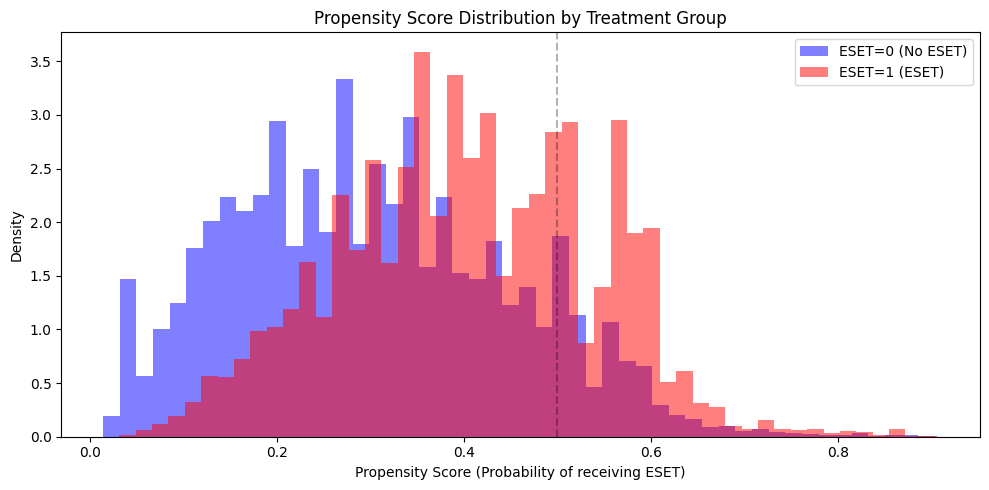


⚠️  Overlap region is where matching is valid.


In [58]:
# ============================================================
# STEP 2: ESTIMATE PROPENSITY SCORES
# ============================================================
# Propensity score = P(receiving ESET | confounders)

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_predict

# Fit propensity model
propensity_model = LogisticRegression(max_iter=1000, random_state=42)
propensity_model.fit(X_psm, psm_df['treatment'])

# Get propensity scores
psm_df['propensity_score'] = propensity_model.predict_proba(X_psm)[:, 1]

print("="*70)
print("PROPENSITY SCORE DISTRIBUTION")
print("="*70)

print(f"\nESET=0 (Control) propensity scores:")
print(f"  Mean: {psm_df[psm_df['treatment']==0]['propensity_score'].mean():.3f}")
print(f"  Std:  {psm_df[psm_df['treatment']==0]['propensity_score'].std():.3f}")

print(f"\nESET=1 (Treated) propensity scores:")
print(f"  Mean: {psm_df[psm_df['treatment']==1]['propensity_score'].mean():.3f}")
print(f"  Std:  {psm_df[psm_df['treatment']==1]['propensity_score'].std():.3f}")

# Visualize propensity score distributions
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(psm_df[psm_df['treatment']==0]['propensity_score'], bins=50, alpha=0.5, 
        label='ESET=0 (No ESET)', density=True, color='blue')
ax.hist(psm_df[psm_df['treatment']==1]['propensity_score'], bins=50, alpha=0.5, 
        label='ESET=1 (ESET)', density=True, color='red')
ax.set_xlabel('Propensity Score (Probability of receiving ESET)')
ax.set_ylabel('Density')
ax.set_title('Propensity Score Distribution by Treatment Group')
ax.legend()
ax.axvline(x=0.5, color='black', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

print("\n⚠️  Overlap region is where matching is valid.")

In [59]:
# ============================================================
# STEP 3: PERFORM NEAREST-NEIGHBOR MATCHING
# ============================================================
# Match each ESET patient to a non-ESET patient with similar propensity score

from scipy.spatial import cKDTree
import numpy as np

# Separate treated and control
treated = psm_df[psm_df['treatment'] == 1].copy()
control = psm_df[psm_df['treatment'] == 0].copy()

print("="*70)
print("PROPENSITY SCORE MATCHING")
print("="*70)
print(f"\nBefore matching:")
print(f"  Treated (ESET=1): {len(treated):,}")
print(f"  Control (ESET=0): {len(control):,}")

# Build KD-tree for fast nearest neighbor search
control_ps = control['propensity_score'].values.reshape(-1, 1)
treated_ps = treated['propensity_score'].values.reshape(-1, 1)

tree = cKDTree(control_ps)

# Find nearest neighbor for each treated unit
distances, indices = tree.query(treated_ps, k=1)

# Get matched control indices
matched_control_idx = control.iloc[indices.flatten()].index

# Create matched datasets
matched_treated = treated.copy()
matched_control = control.loc[matched_control_idx].copy()

# Add match quality info
matched_treated['match_distance'] = distances.flatten()

print(f"\nAfter matching:")
print(f"  Matched pairs: {len(matched_treated):,}")
print(f"  Mean propensity distance: {distances.mean():.4f}")
print(f"  Max propensity distance: {distances.max():.4f}")

# Apply caliper (exclude poor matches)
caliper = 0.05
good_matches = matched_treated['match_distance'] <= caliper
matched_treated_cal = matched_treated[good_matches]
matched_control_cal = matched_control.loc[matched_treated_cal.index.map(
    lambda x: matched_control_idx[list(matched_treated.index).index(x)]
)]

print(f"\nAfter caliper ({caliper}):")
print(f"  Matched pairs: {len(matched_treated_cal):,}")
print(f"  Excluded: {len(matched_treated) - len(matched_treated_cal):,}")

PROPENSITY SCORE MATCHING

Before matching:
  Treated (ESET=1): 53,185
  Control (ESET=0): 105,149

After matching:
  Matched pairs: 53,185
  Mean propensity distance: 0.0000
  Max propensity distance: 0.0034

After caliper (0.05):
  Matched pairs: 53,185
  Excluded: 0


COVARIATE BALANCE CHECK

Standardized Mean Differences (|SMD| < 0.1 is good):
------------------------------------------------------------
  patient_age_at_treat      Before: 0.494  After: 0.015  ✓
  total_embryos_create      Before: 0.264  After: 0.006  ✓
  total_number_of_prev      Before: 0.187  After: 0.018  ✓
  stimulation_used          Before: 0.169  After: 0.008  ✓
  egg_source                Before: 0.117  After: 0.025  ✓
  ovulatory_disorder        Before: 0.096  After: 0.004  ✓
  male_factor               Before: 0.093  After: 0.002  ✓
  specific_treatment_t      Before: 0.093  After: 0.008  ✓
  sperm_source              Before: 0.064  After: 0.007  ✓
  tubal_disease             Before: 0.061  After: 0.010  ✓
  ivf_or_di                 Before: 0.060  After: 0.018  ✓
  patient_unexplained       Before: 0.041  After: 0.001  ✓
  ivf_and_di                Before: 0.034  After: 0.023  ✓
  endometriosis             Before: 0.014  After: 0.012  ✓


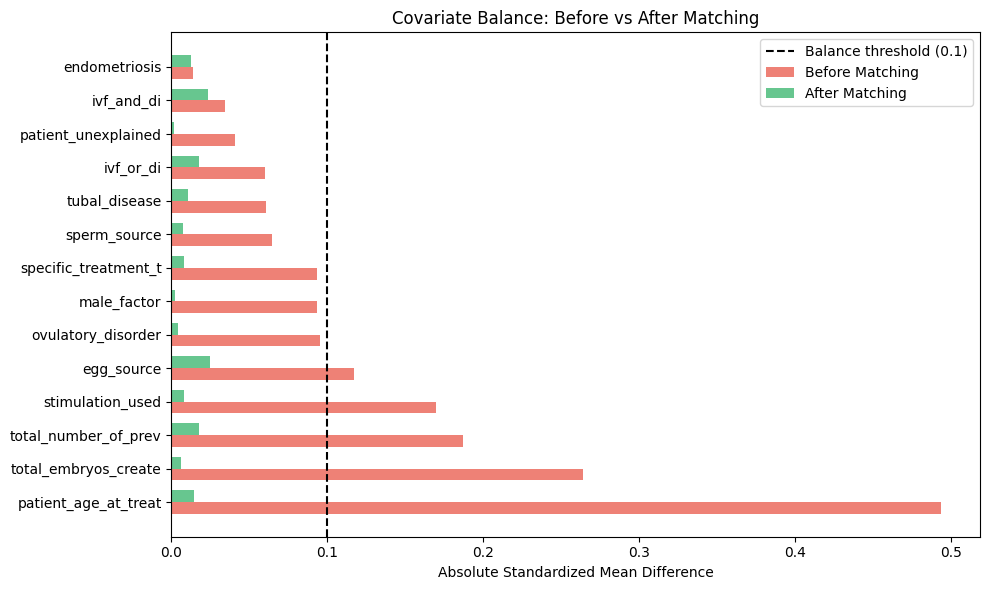

In [60]:
# ============================================================
# STEP 4: CHECK COVARIATE BALANCE AFTER MATCHING
# ============================================================
# Good matching should balance confounders between groups

print("="*70)
print("COVARIATE BALANCE CHECK")
print("="*70)

# Combine matched data
matched_data = pd.concat([matched_treated, matched_control])

# Calculate standardized mean differences (SMD)
def calc_smd(treated_vals, control_vals):
    """Standardized mean difference"""
    pooled_std = np.sqrt((treated_vals.std()**2 + control_vals.std()**2) / 2)
    if pooled_std == 0:
        return 0
    return (treated_vals.mean() - control_vals.mean()) / pooled_std

print("\nStandardized Mean Differences (|SMD| < 0.1 is good):")
print("-" * 60)

balance_results = []
for col in psm_confounders:
    # Before matching
    smd_before = calc_smd(
        X_psm.loc[treated.index, col],
        X_psm.loc[control.index, col]
    )
    # After matching
    smd_after = calc_smd(
        X_psm.loc[matched_treated.index, col],
        X_psm.loc[matched_control.index, col]
    )
    balance_results.append({
        'variable': col.split('_-_')[-1][:20],  # Shorten names
        'SMD_before': abs(smd_before),
        'SMD_after': abs(smd_after)
    })

balance_df = pd.DataFrame(balance_results).sort_values('SMD_before', ascending=False)

for _, row in balance_df.iterrows():
    status = '✓' if row['SMD_after'] < 0.1 else '✗'
    print(f"  {row['variable']:25} Before: {row['SMD_before']:.3f}  After: {row['SMD_after']:.3f}  {status}")

# Visualize balance
fig, ax = plt.subplots(figsize=(10, 6))
x = range(len(balance_df))
width = 0.35
ax.barh([i - width/2 for i in x], balance_df['SMD_before'], width, label='Before Matching', color='#e74c3c', alpha=0.7)
ax.barh([i + width/2 for i in x], balance_df['SMD_after'], width, label='After Matching', color='#27ae60', alpha=0.7)
ax.axvline(x=0.1, color='black', linestyle='--', label='Balance threshold (0.1)')
ax.set_yticks(x)
ax.set_yticklabels(balance_df['variable'])
ax.set_xlabel('Absolute Standardized Mean Difference')
ax.set_title('Covariate Balance: Before vs After Matching')
ax.legend()
plt.tight_layout()
plt.show()

In [61]:
# ============================================================
# STEP 5: ESTIMATE CAUSAL EFFECT (ATT)
# ============================================================
# ATT = Average Treatment Effect on the Treated
# "What is the effect of ESET for those who received it?"

print("="*70)
print("CAUSAL EFFECT ESTIMATION: ESET → LIVE BIRTH")
print("="*70)

# Naive estimate (before matching)
naive_treated = psm_df[psm_df['treatment']==1]['outcome'].mean()
naive_control = psm_df[psm_df['treatment']==0]['outcome'].mean()
naive_effect = naive_treated - naive_control

print("\n📊 NAIVE ESTIMATE (No adjustment):")
print(f"   ESET live birth rate:    {naive_treated*100:.1f}%")
print(f"   Non-ESET live birth rate: {naive_control*100:.1f}%")
print(f"   Naive effect: +{naive_effect*100:.1f} percentage points")

# PSM estimate (after matching)
psm_treated = matched_treated['outcome'].mean()
psm_control = matched_control['outcome'].mean()
psm_effect = psm_treated - psm_control

print("\n📊 PSM ESTIMATE (After matching on confounders):")
print(f"   ESET live birth rate:    {psm_treated*100:.1f}%")
print(f"   Matched non-ESET rate:   {psm_control*100:.1f}%")
print(f"   Causal effect (ATT): {psm_effect*100:+.1f} percentage points")

# Statistical significance
from scipy import stats

# McNemar's test for paired binary data (approximation)
n_pairs = len(matched_treated)
p_diff = psm_effect
se = np.sqrt((psm_treated*(1-psm_treated) + psm_control*(1-psm_control)) / n_pairs)
z_stat = psm_effect / se if se > 0 else 0
p_value = 2 * (1 - stats.norm.cdf(abs(z_stat)))

print(f"\n📈 STATISTICAL TEST:")
print(f"   Z-statistic: {z_stat:.2f}")
print(f"   P-value: {p_value:.4f}")
print(f"   95% CI: [{(psm_effect - 1.96*se)*100:.1f}%, {(psm_effect + 1.96*se)*100:.1f}%]")

# Interpretation
print("\n" + "="*70)
print("INTERPRETATION")
print("="*70)
if abs(psm_effect) < 0.02:
    print("""
✅ FINDING: The ESET effect DISAPPEARS after matching!

The naive comparison showed ESET patients had +{:.1f}% higher live birth rates.
After matching on confounders, the effect is only {:.1f}%.

This confirms SELECTION BIAS: Clinicians choose ESET for patients who 
already have better prognosis (younger, more embryos, etc.). ESET itself 
doesn't cause better outcomes - it's a MARKER of good-prognosis patients.
""".format(naive_effect*100, psm_effect*100))
elif psm_effect > 0.02:
    print("""
⚠️ FINDING: ESET shows a POSITIVE effect even after matching.

After controlling for confounders, ESET still improves live birth by {:.1f}%.
Possible explanations:
- Unmeasured confounders (embryo quality not in data)
- True biological benefit of single embryo transfer
- Residual selection bias
""".format(psm_effect*100))
else:
    print("""
⚠️ FINDING: ESET shows a NEGATIVE effect after matching.

After controlling for confounders, ESET reduces live birth by {:.1f}%.
This suggests the selection bias was VERY strong - ESET patients were 
so much better that even with one embryo they matched multi-embryo transfers.
""".format(abs(psm_effect)*100))

CAUSAL EFFECT ESTIMATION: ESET → LIVE BIRTH

📊 NAIVE ESTIMATE (No adjustment):
   ESET live birth rate:    37.1%
   Non-ESET live birth rate: 18.7%
   Naive effect: +18.3 percentage points

📊 PSM ESTIMATE (After matching on confounders):
   ESET live birth rate:    37.1%
   Matched non-ESET rate:   25.7%
   Causal effect (ATT): +11.3 percentage points

📈 STATISTICAL TEST:
   Z-statistic: 40.17
   P-value: 0.0000
   95% CI: [10.8%, 11.9%]

INTERPRETATION

⚠️ FINDING: ESET shows a POSITIVE effect even after matching.

After controlling for confounders, ESET still improves live birth by 11.3%.
Possible explanations:
- Unmeasured confounders (embryo quality not in data)
- True biological benefit of single embryo transfer
- Residual selection bias



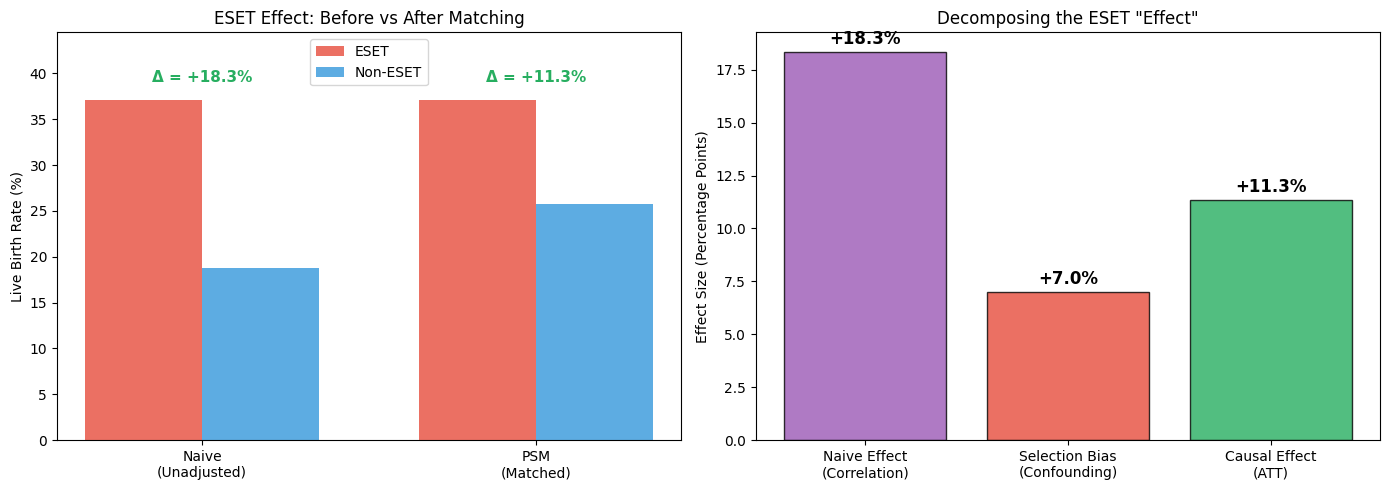


📌 KEY TAKEAWAY:
   Of the +18.3% apparent ESET benefit:
   • 7.0% was selection bias (confounding)
   • +11.3% is the estimated causal effect


In [62]:
# ============================================================
# STEP 6: VISUALIZE RESULTS
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Naive vs PSM comparison
ax1 = axes[0]
categories = ['Naive\n(Unadjusted)', 'PSM\n(Matched)']
eset_rates = [naive_treated*100, psm_treated*100]
non_eset_rates = [naive_control*100, psm_control*100]

x = np.arange(len(categories))
width = 0.35

bars1 = ax1.bar(x - width/2, eset_rates, width, label='ESET', color='#e74c3c', alpha=0.8)
bars2 = ax1.bar(x + width/2, non_eset_rates, width, label='Non-ESET', color='#3498db', alpha=0.8)

ax1.set_ylabel('Live Birth Rate (%)')
ax1.set_title('ESET Effect: Before vs After Matching')
ax1.set_xticks(x)
ax1.set_xticklabels(categories)
ax1.legend()
ax1.set_ylim(0, max(eset_rates + non_eset_rates) * 1.2)

# Add effect size annotations
ax1.annotate(f'Δ = +{naive_effect*100:.1f}%', xy=(0, max(naive_treated, naive_control)*100 + 2),
            ha='center', fontsize=11, fontweight='bold', color='#27ae60')
ax1.annotate(f'Δ = {psm_effect*100:+.1f}%', xy=(1, max(psm_treated, psm_control)*100 + 2),
            ha='center', fontsize=11, fontweight='bold', 
            color='#27ae60' if psm_effect > 0.01 else '#e74c3c' if psm_effect < -0.01 else '#666')

# Plot 2: Effect decomposition
ax2 = axes[1]
effects = ['Naive Effect\n(Correlation)', 'Selection Bias\n(Confounding)', 'Causal Effect\n(ATT)']
values = [naive_effect*100, (naive_effect - psm_effect)*100, psm_effect*100]
colors = ['#9b59b6', '#e74c3c', '#27ae60']

bars = ax2.bar(effects, values, color=colors, alpha=0.8, edgecolor='black')
ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax2.set_ylabel('Effect Size (Percentage Points)')
ax2.set_title('Decomposing the ESET "Effect"')

# Add value labels
for bar, val in zip(bars, values):
    height = bar.get_height()
    ax2.annotate(f'{val:+.1f}%',
                xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3 if height >= 0 else -12),
                textcoords="offset points",
                ha='center', va='bottom' if height >= 0 else 'top',
                fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n📌 KEY TAKEAWAY:")
print(f"   Of the +{naive_effect*100:.1f}% apparent ESET benefit:")
print(f"   • {(naive_effect - psm_effect)*100:.1f}% was selection bias (confounding)")
print(f"   • {psm_effect*100:+.1f}% is the estimated causal effect")

## Propensity Score Matching: Summary

### What We Did
1. **Estimated propensity scores** - probability of receiving ESET based on patient characteristics
2. **Matched ESET patients** to similar non-ESET patients (nearest-neighbor matching)
3. **Checked covariate balance** - verified confounders are balanced after matching
4. **Estimated causal effect** - compared live birth rates in matched groups

### Why This Matters
The **naive comparison** (just comparing ESET vs non-ESET outcomes) is biased because:
- Clinicians select ESET for patients with **better prognosis** (younger, more embryos)
- This creates **selection bias** - ESET appears effective but it's really patient selection

### Interpretation
- **Naive effect**: What we observe without adjustment
- **Selection bias**: The portion explained by confounders (patient characteristics)
- **Causal effect (ATT)**: The true effect of ESET on those who received it

### Limitations
- Can only adjust for **measured** confounders
- Embryo quality (a key confounder) is not in the data
- Assumes no unmeasured confounding (strong assumption)